# Analisis de conectividad del subte de CABA

Este notebook busca responder dos preguntas de forma clara e intuitiva:

1. Como esta organizada la red de subte y donde se concentran los transbordos.
2. Que estaciones ocupan posiciones mas centrales y cuales quedan mas perifericas cuando se pondera el tiempo de viaje.

Las visualizaciones se simplificaron para evitar saturacion: se etiquetan solo estaciones clave, se distinguen los transbordos con linea punteada y las metricas se muestran con una breve interpretacion.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analisis_conectividad_subte_caba import generate_outputs

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / 'figures'
OUTPUT_DIR = BASE_DIR / 'outputs'

results = generate_outputs()
checks = results['checks']
stats = results['stats']
summary = results['summary']
line_summary = results['line_summary']
top_central = results['top_central']
top_peripheral = results['top_peripheral']
future = results['future']

## 1. Verificacion de consistencia

Antes de interpretar la red, conviene validar que el modelo este bien construido.
Los chequeos de abajo confirman que:

- las 89 estaciones aparecen en el grafo,
- no faltan posiciones geograficas ni esquematicas,
- todas las estaciones estan conectadas al resto de la red.

In [2]:
pd.DataFrame(
    {
        'indicador': list(checks.keys()) + list(stats.keys()),
        'valor': list(checks.values()) + list(stats.values()),
    }
)

,indicador,valor
0,estaciones,89
1,conexiones,97
2,nodos_grafo,89
3,grafo_conexo,True
4,ids_sin_conexion,0
5,ids_sin_pos_geo,0
6,ids_sin_pos_diag,0
7,nodos,89
8,aristas,97
9,transbordos,14


## 2. Estructura general de la red

La vista geografica ayuda a ubicar la red en la ciudad. La vista esquematica, en cambio, facilita leer la topologia: donde se cruzan lineas, donde aparecen los corredores mas largos y como se distribuyen los transbordos.

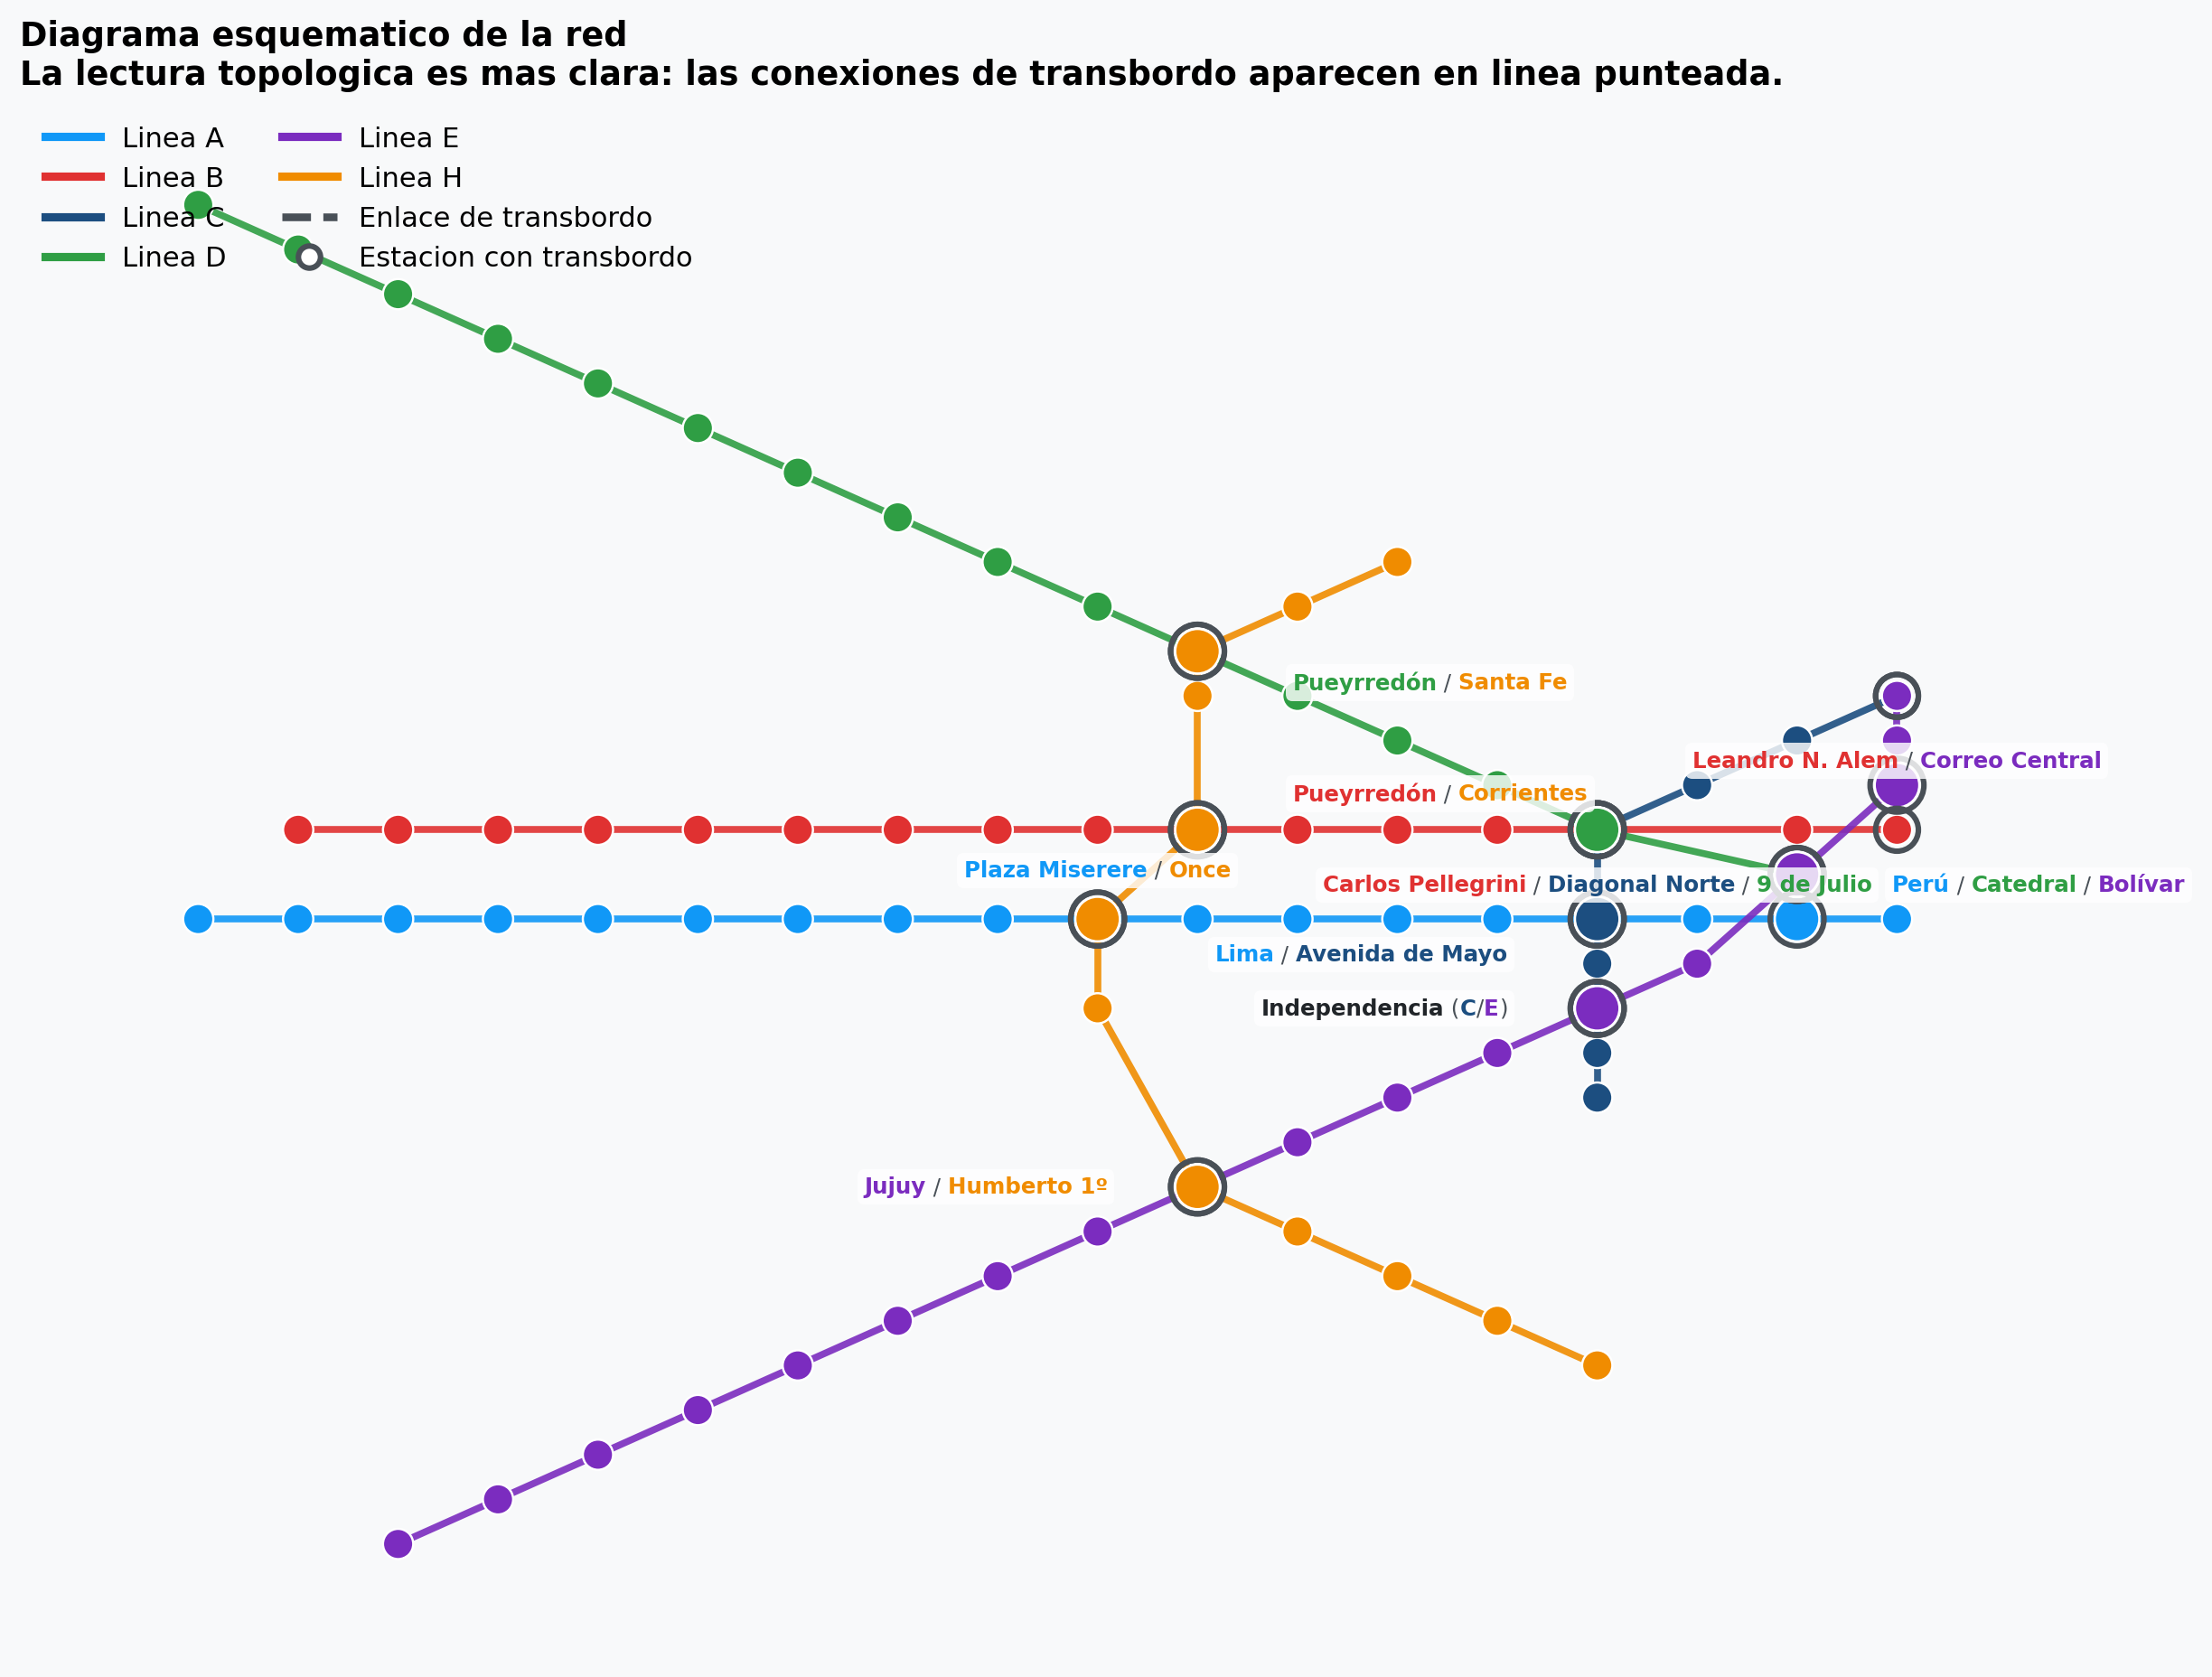

In [3]:
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_mapa_geografico.png')))
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_mapa_esquematico.png')))

Lectura rapida:

- Las lineas A, B, D y E concentran buena parte de la estructura longitudinal.
- Los transbordos se agrupan sobre todo en el area central.
- La linea H funciona como un conector transversal clave entre varios corredores radiales.

## 3. Estaciones mas centrales

Se usan metricas ponderadas por tiempo de viaje. Dos de las mas utiles para interpretar la red son:

- **Betweenness**: mide cuanto actua una estacion como puente en rutas minimas.
- **Closeness**: mide que tan rapido se llega desde una estacion al resto de la red.

En los mapas siguientes, los nodos mas grandes y oscuros concentran valores mas altos.

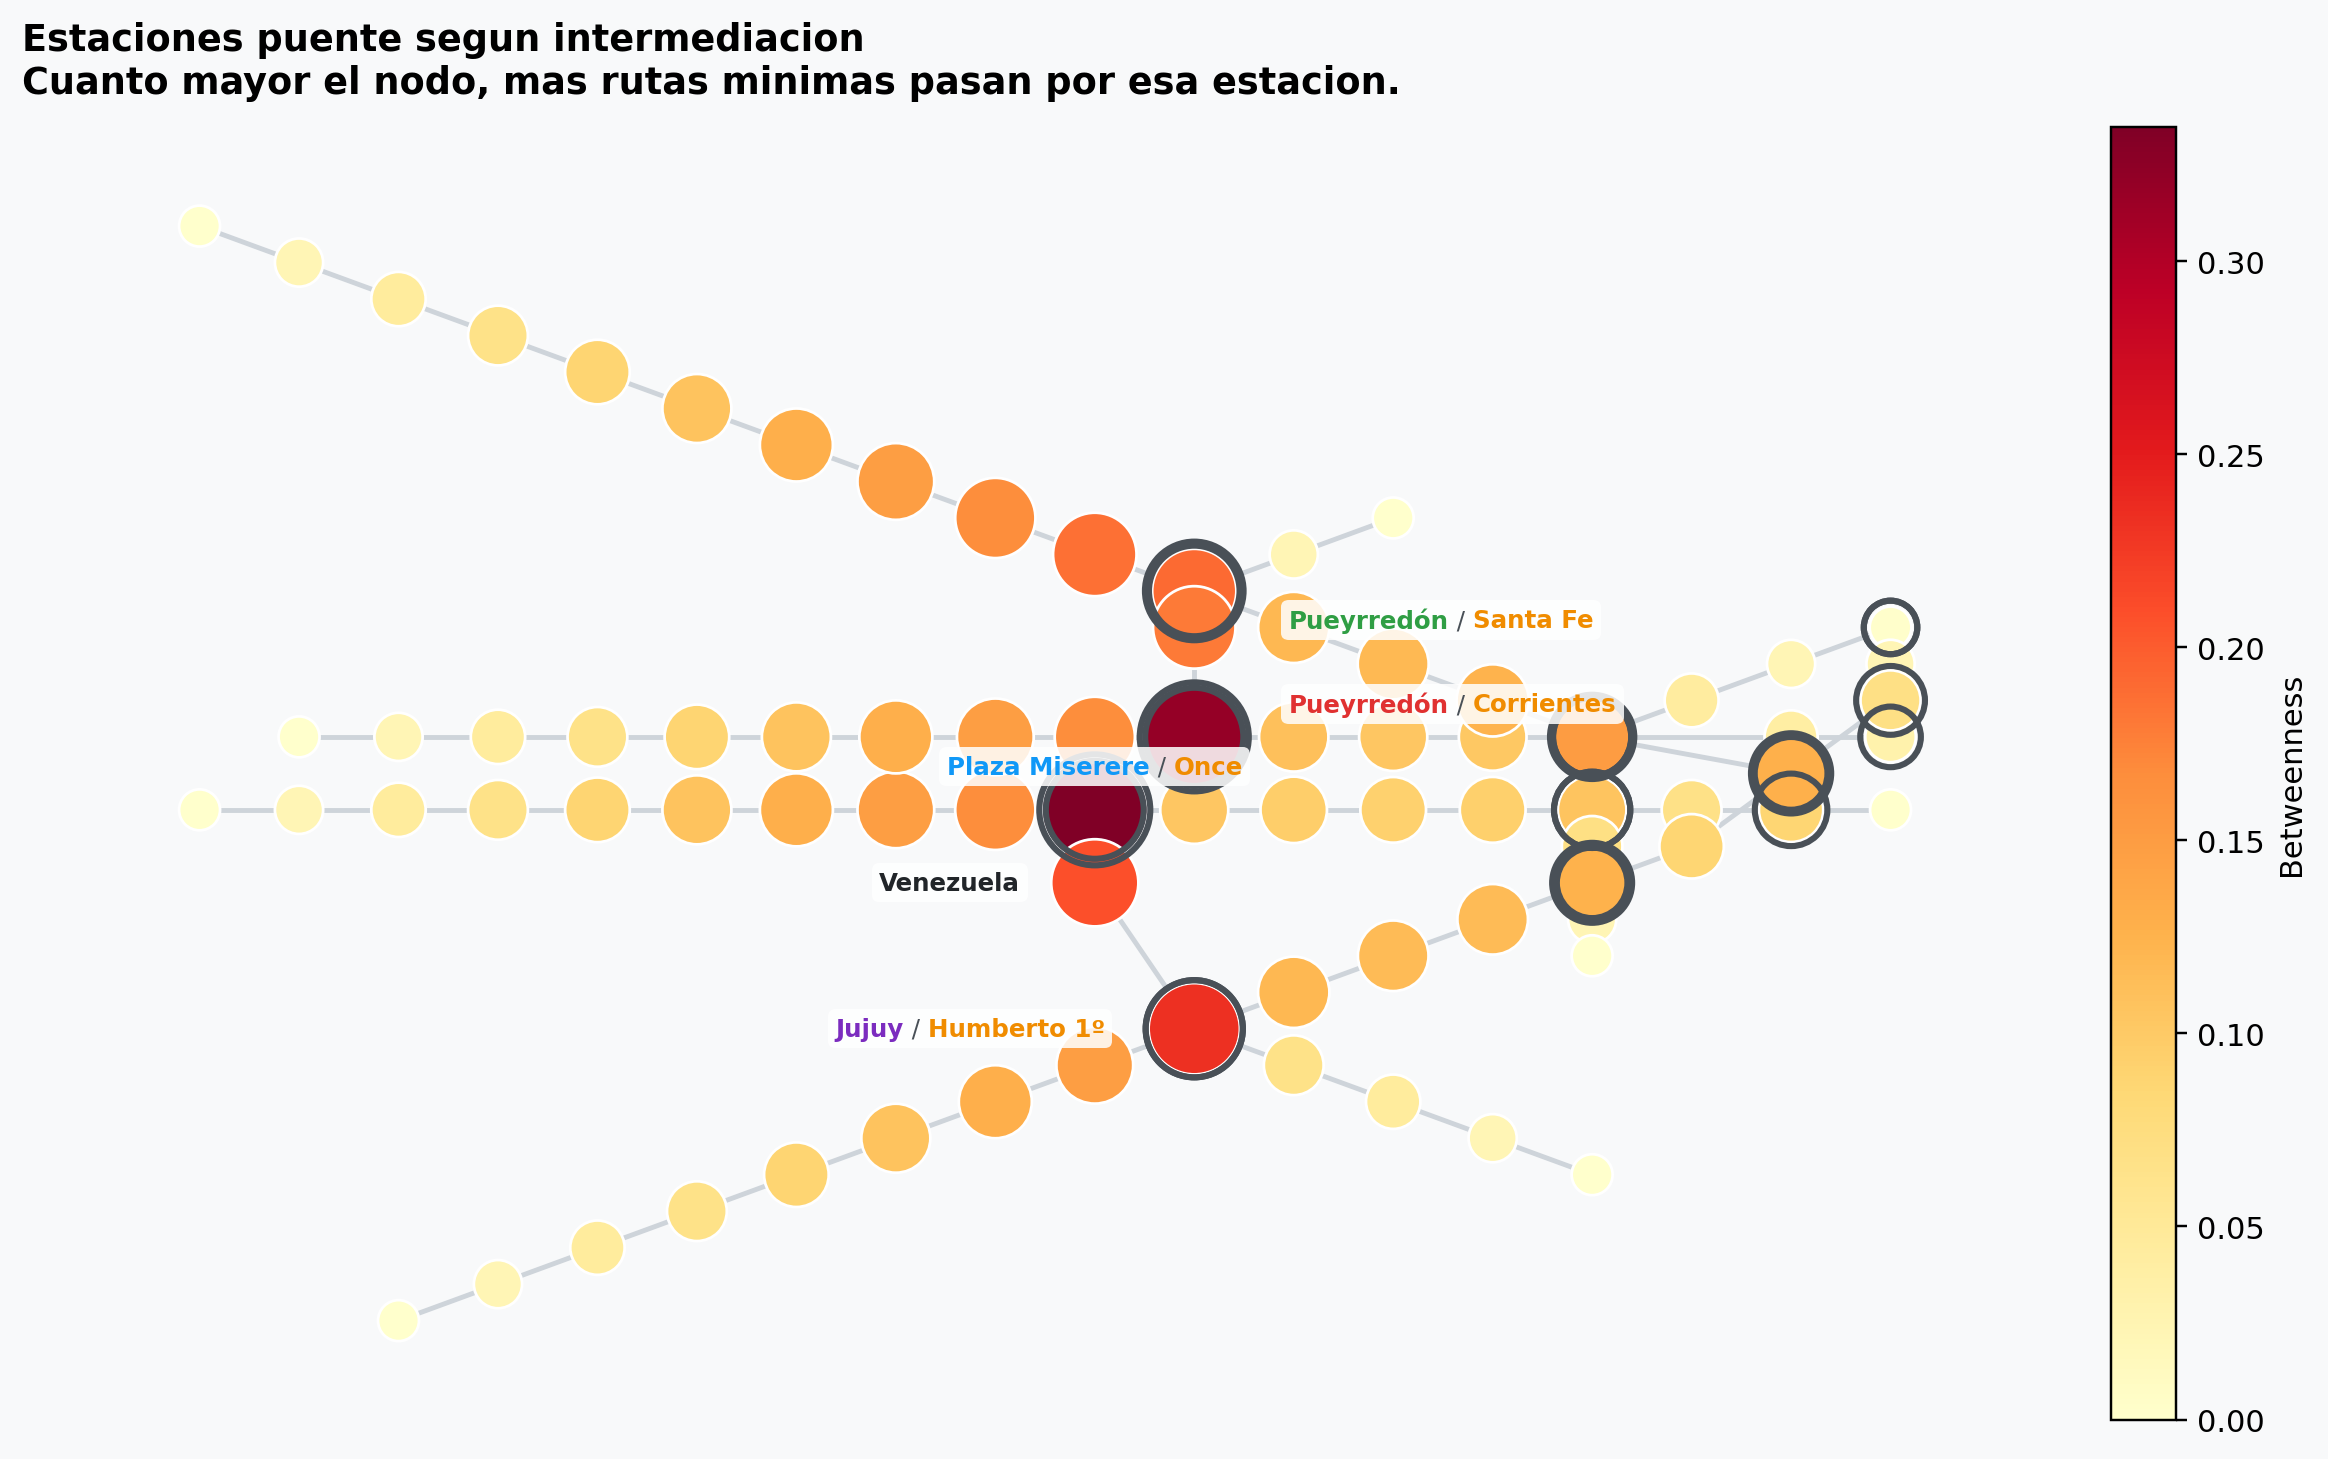

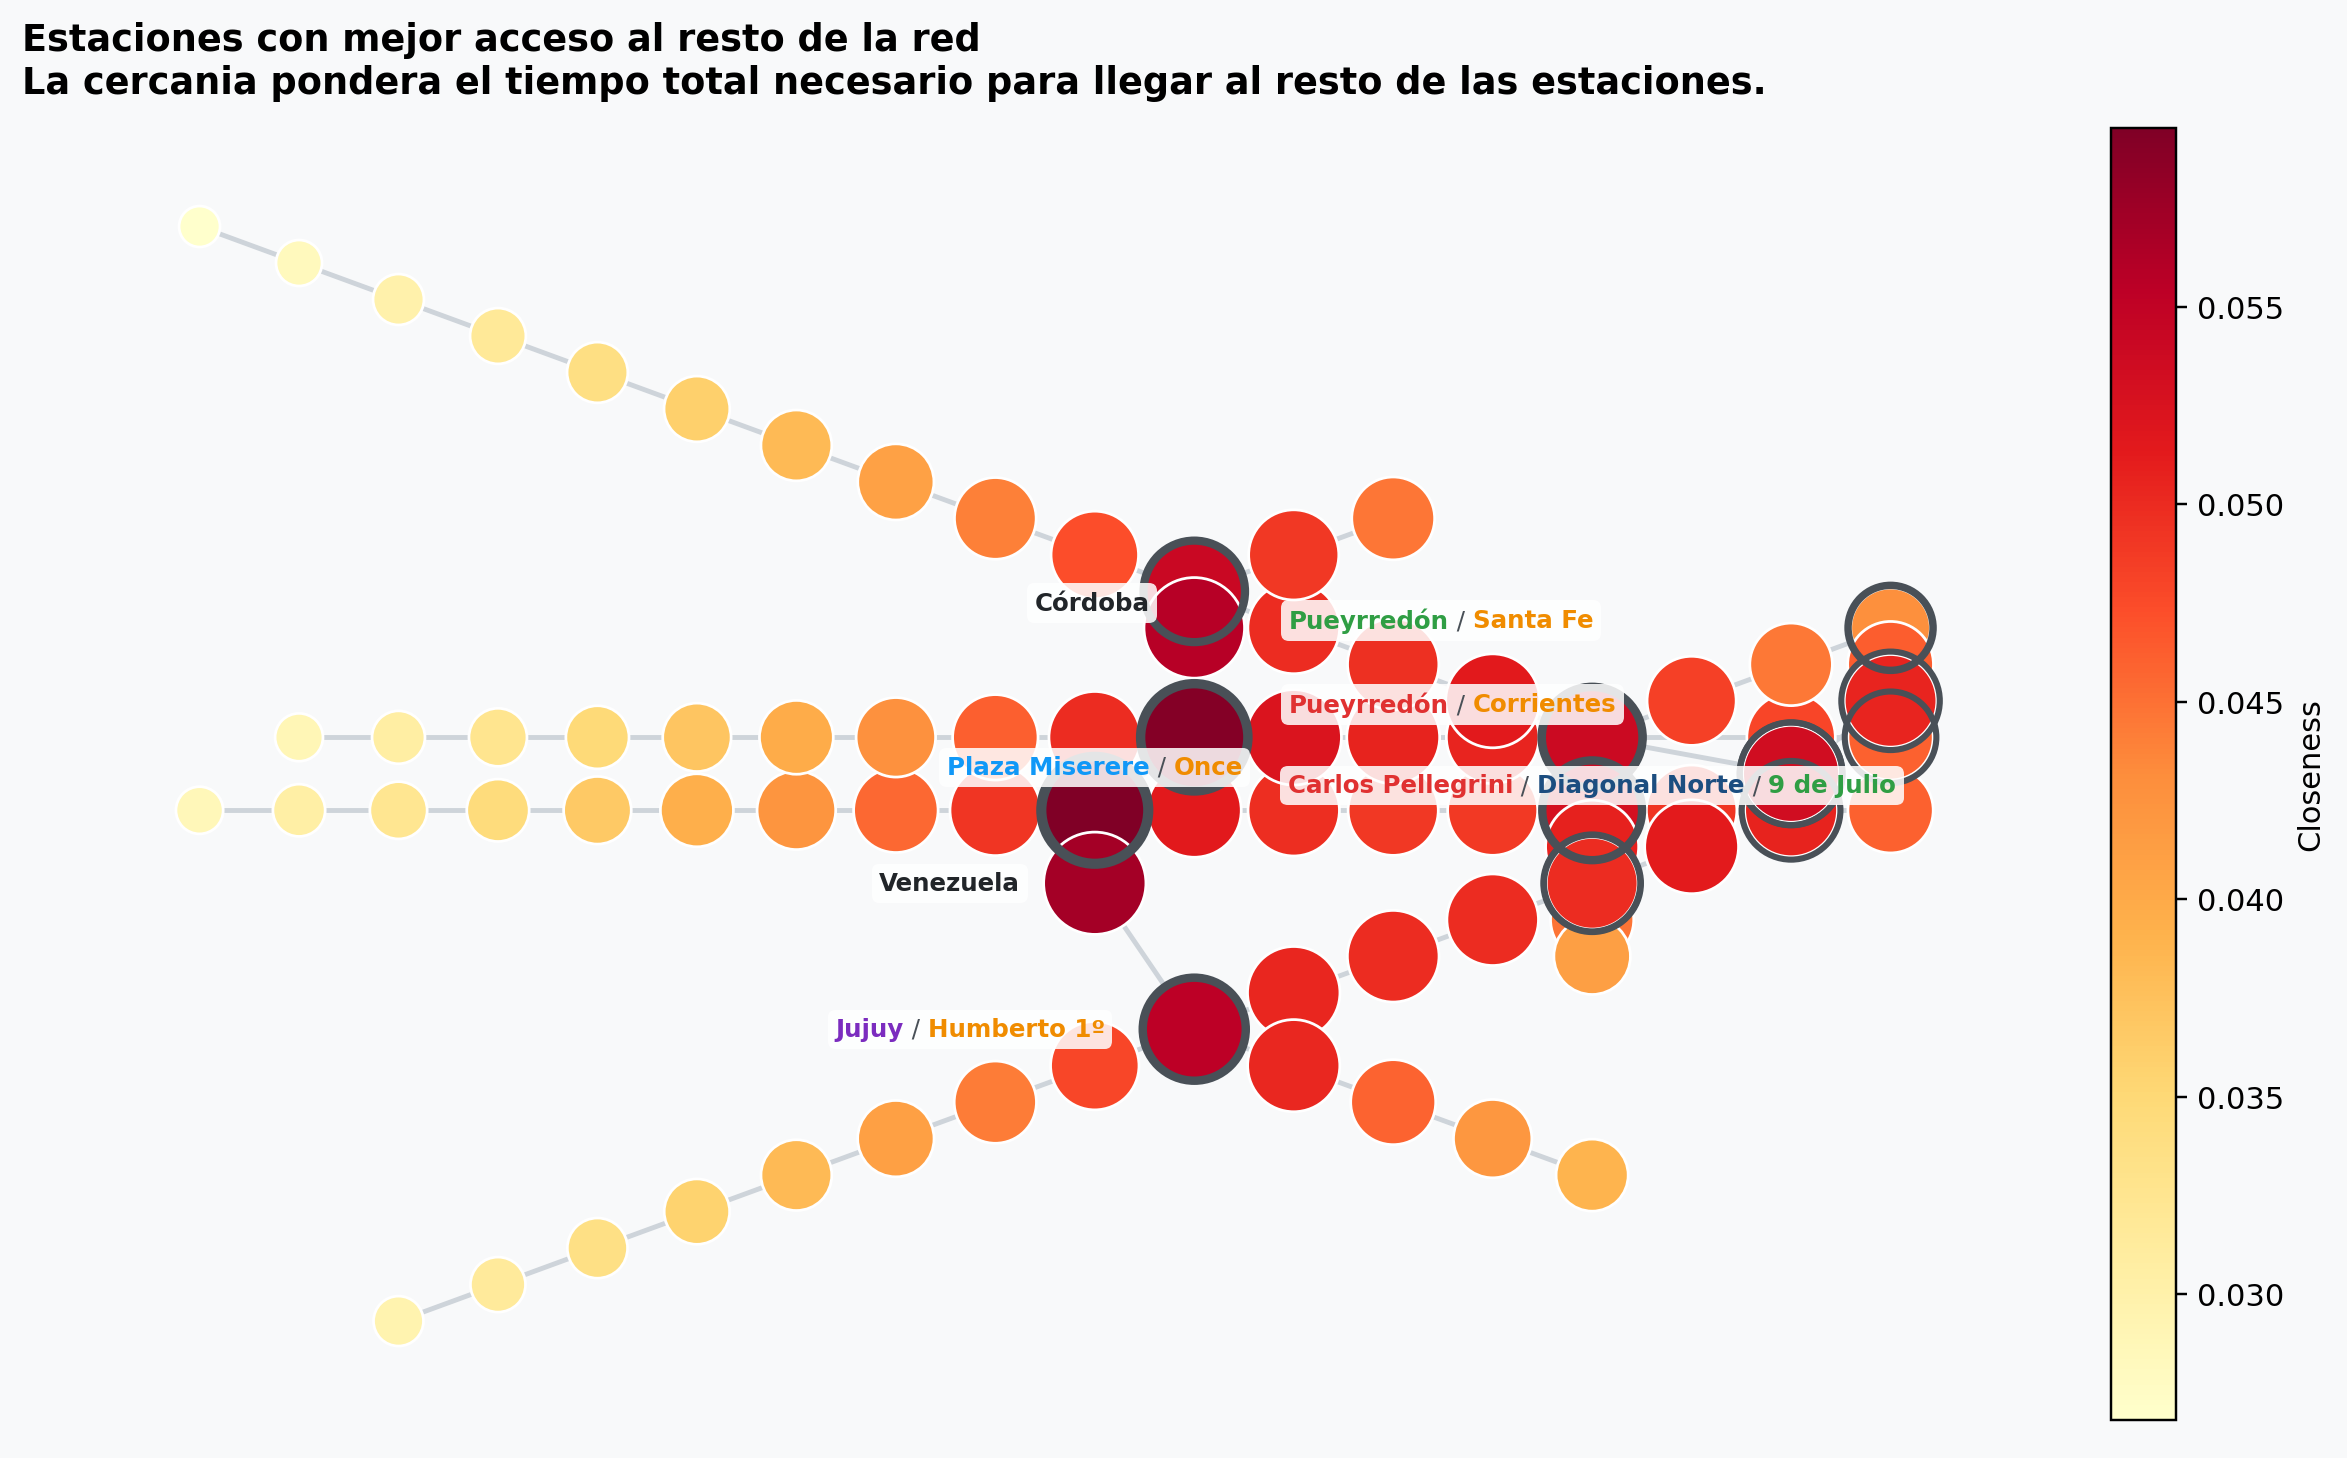

In [4]:
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_intermediacion.png')))
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_cercania.png')))

El ranking agregado combina grado, intermediacion, cercania, autovector y baja excentricidad. Un score menor implica una posicion mas central dentro de la red.

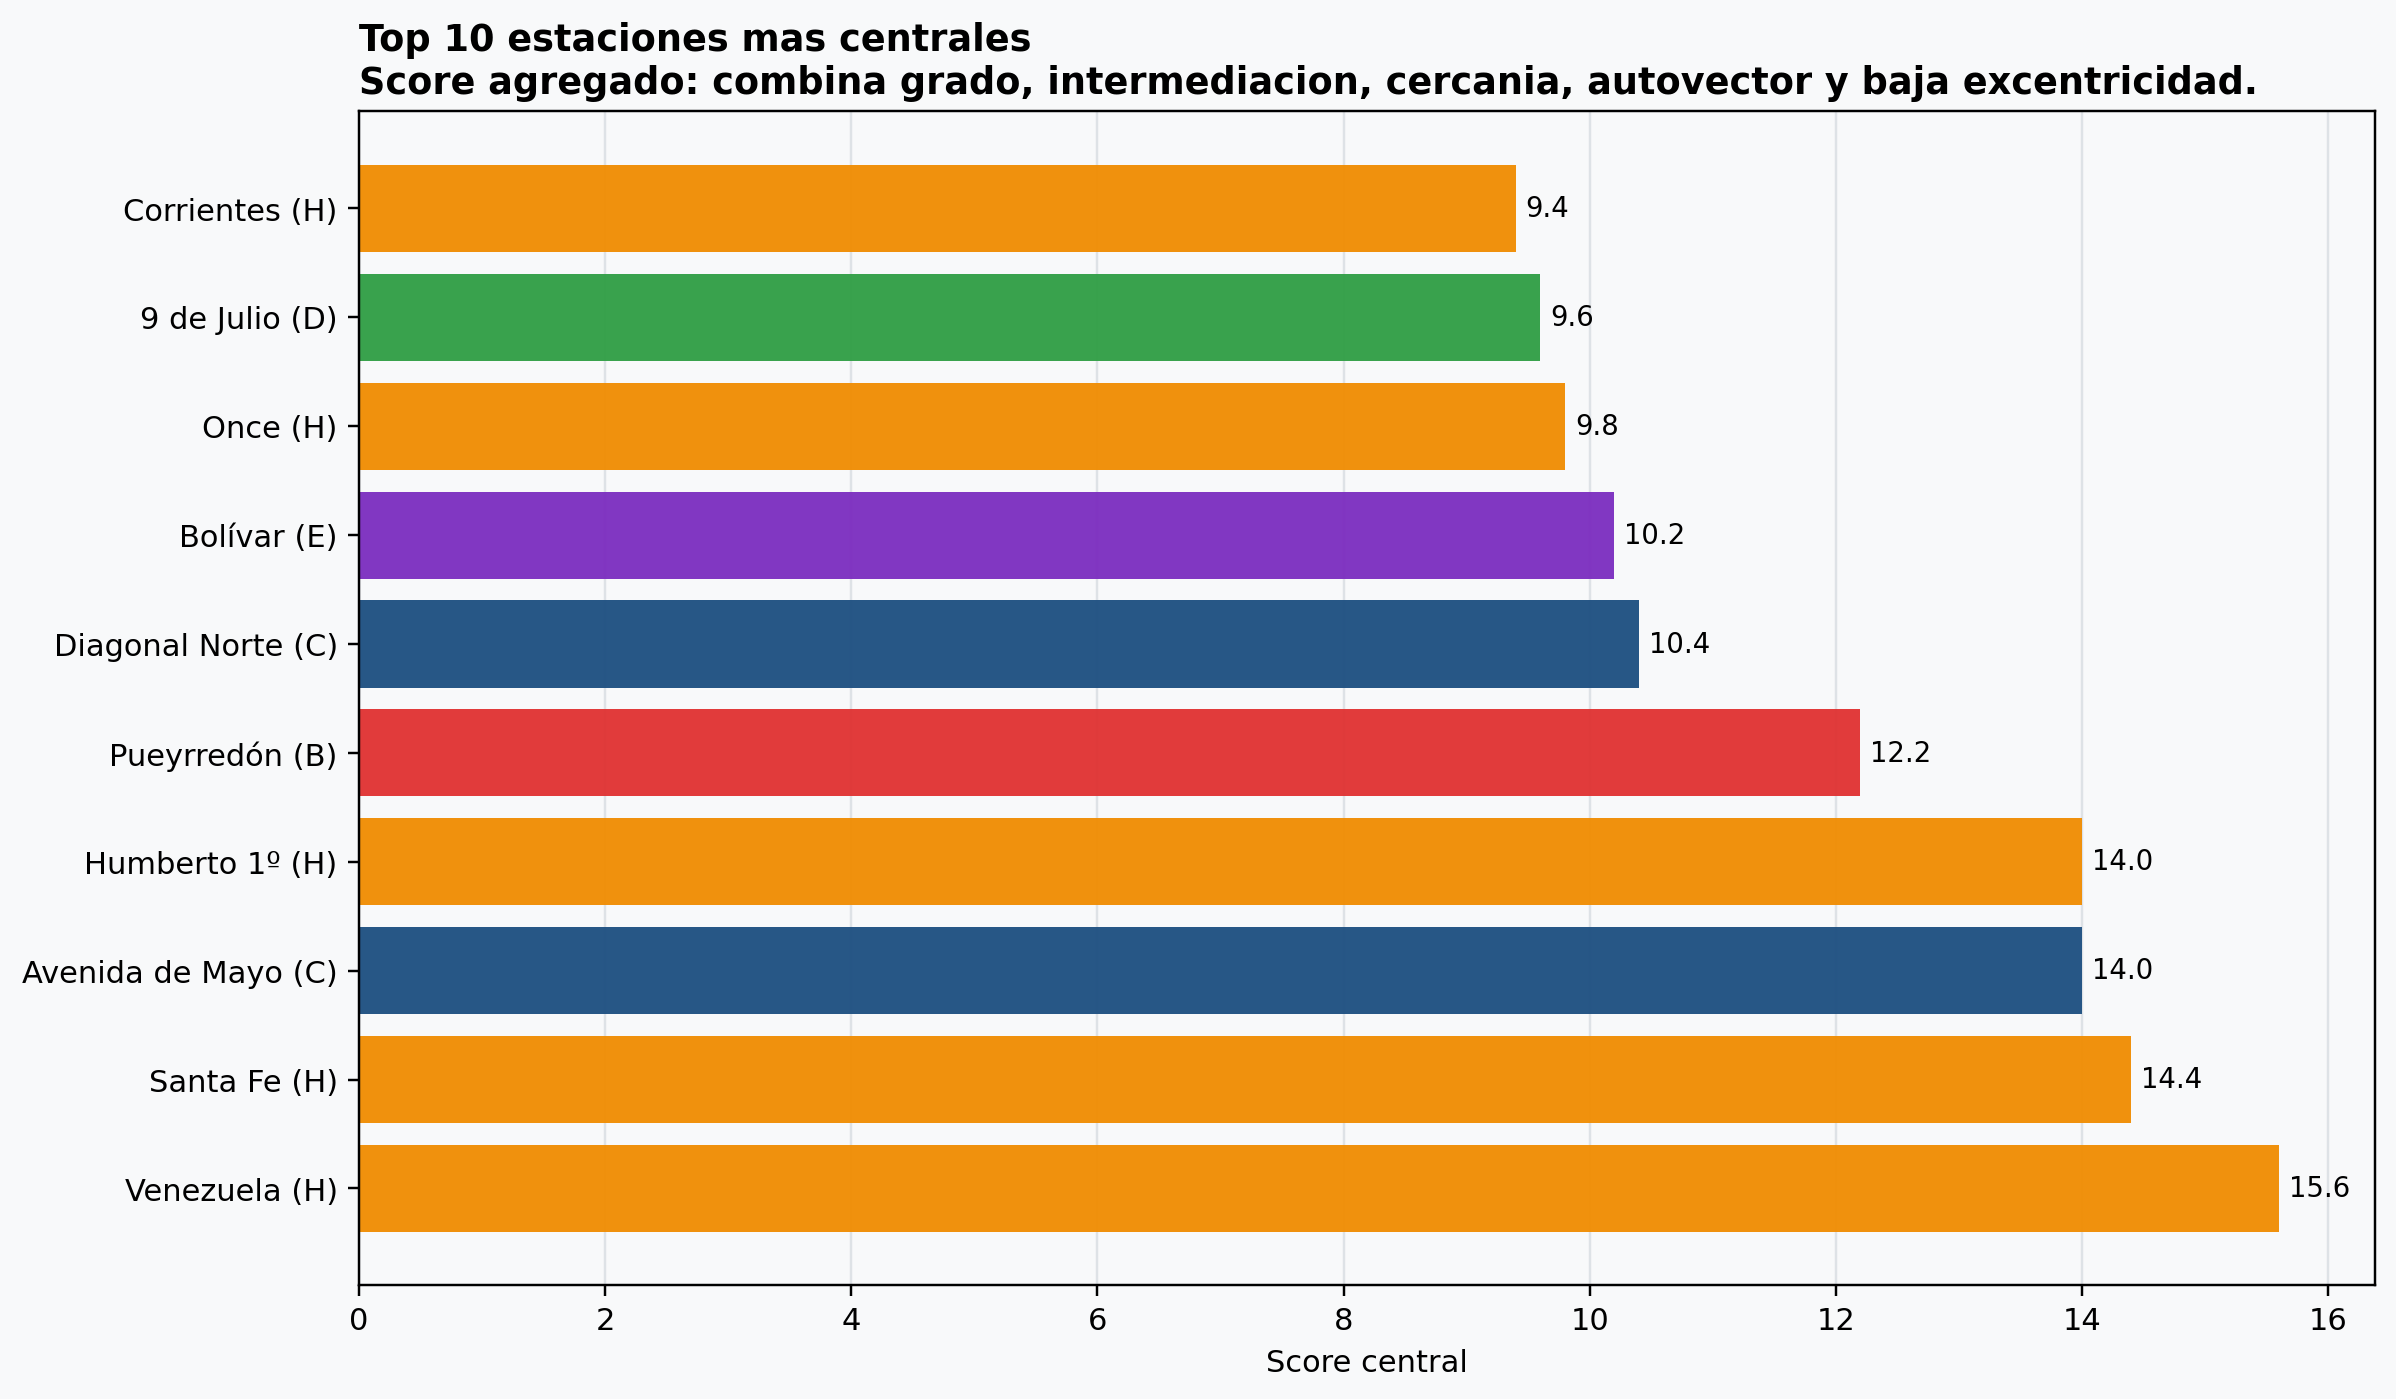

,estacion,linea,grado,betweenness,closeness,autovector,excentricidad,score_central,score_periferico
81,Corrientes,H,3.0,0.319575,0.059219,0.068398,31,9.4,77.8
44,9 de Julio,D,4.0,0.151341,0.053856,0.240146,39,9.6,78.8
82,Once,H,3.0,0.334727,0.059540,0.067405,33,9.8,77.4
59,Bolívar,E,4.0,0.127743,0.053301,0.277803,38,10.2,78.0
37,Diagonal Norte,C,4.0,0.116597,0.052916,0.259321,35,10.4,78.4
24,Pueyrredón,B,3.0,0.240204,0.054321,0.067455,36,12.2,75.0
84,Humberto 1º,H,3.0,0.233804,0.055346,0.057232,37,14.0,72.8
38,Avenida de Mayo,C,3.0,0.106017,0.052948,0.252600,36,14.0,73.2
79,Santa Fe,H,3.0,0.189916,0.054087,0.045904,31,14.4,72.8
83,Venezuela,H,2.0,0.207941,0.056995,0.057828,35,15.6,61.8


In [5]:
display(Image(filename=str(FIGURES_DIR / 'ranking_estaciones_centrales.png')))
top_central

Interpretacion:

- **Corrientes** y **Once** aparecen arriba porque conectan varios recorridos y quedan bien posicionadas para redistribuir viajes.
- **9 de Julio**, **Bolivar** y **Diagonal Norte** combinan mucha conectividad con ubicacion central.
- La presencia repetida de estaciones de la linea H confirma su rol articulador en la red actual.

## 4. Estaciones mas perifericas

La excentricidad captura cuan lejos queda cada estacion de su punto mas lejano dentro de la red. Para la periferia conviene mirar dos cosas juntas:

- valores altos de excentricidad,
- scores agregados que reflejen baja conectividad relativa.

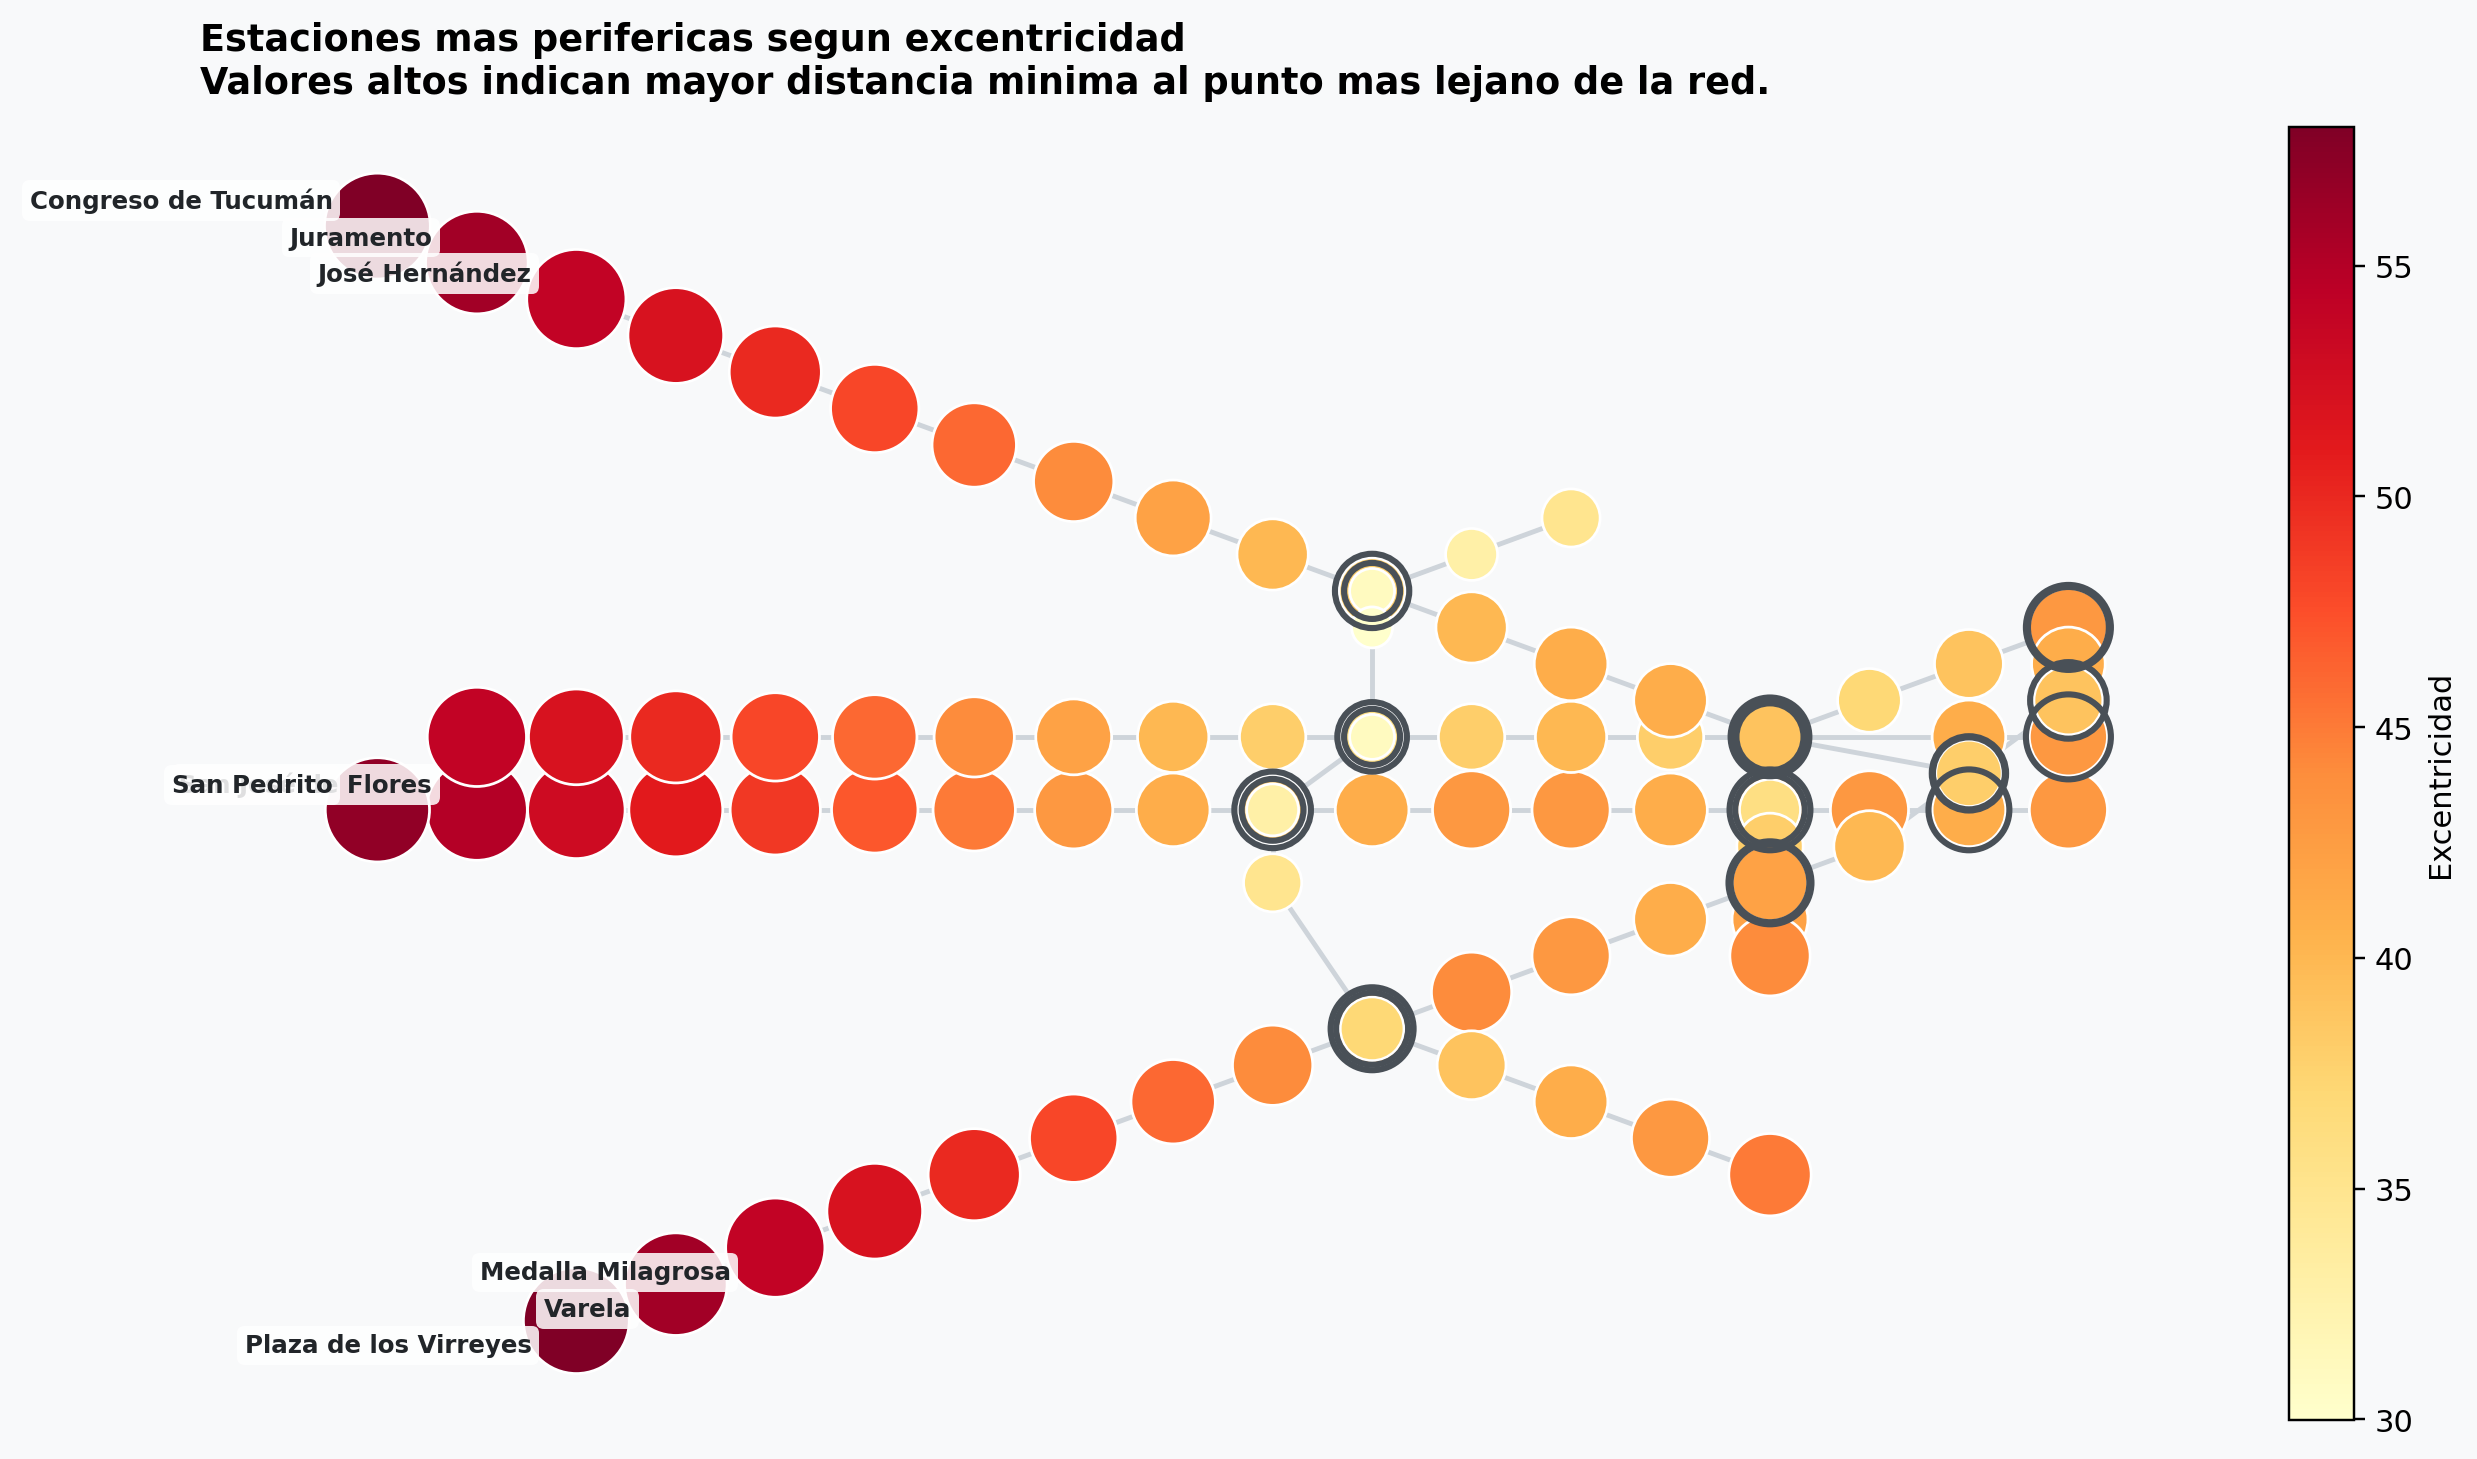

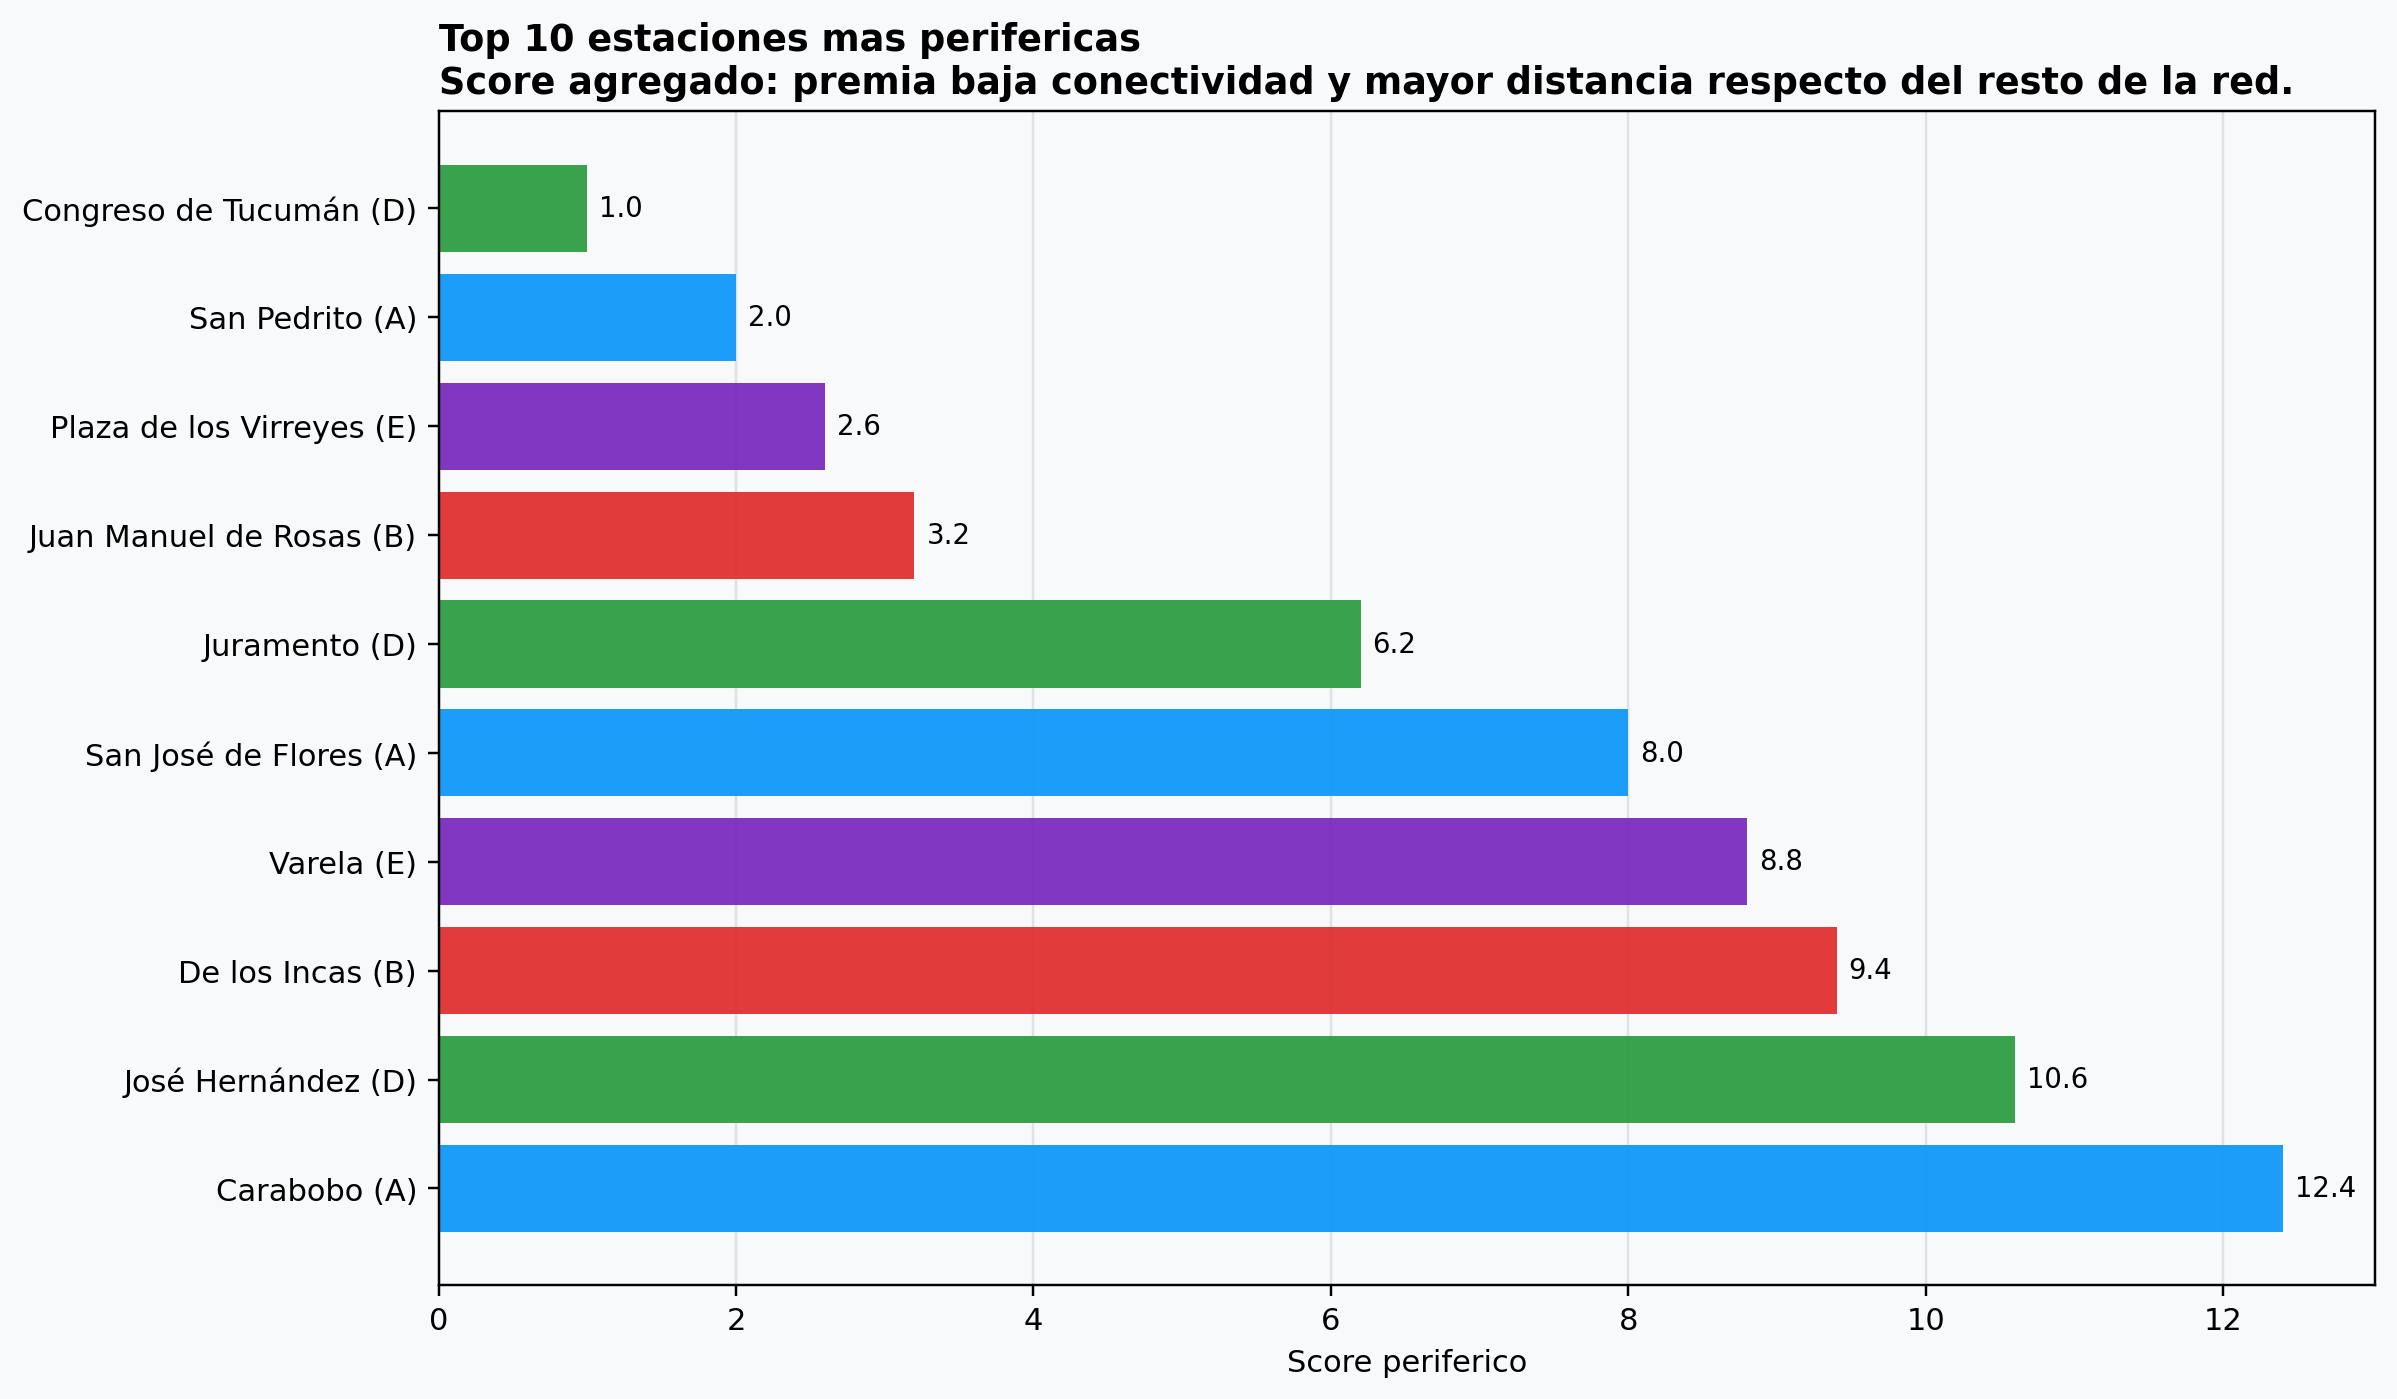

,estacion,linea,grado,betweenness,closeness,autovector,excentricidad,score_central,score_periferico
58,Congreso de Tucumán,D,1.0,0.000000,0.026821,0.000710,58,86.0,1.0
17,San Pedrito,A,1.0,0.000000,0.028711,0.000916,57,85.2,2.0
73,Plaza de los Virreyes,E,1.0,0.000000,0.029620,0.001645,58,84.4,2.6
33,Juan Manuel de Rosas,B,1.0,0.000000,0.028928,0.001081,54,83.6,3.2
57,Juramento,D,2.0,0.022727,0.028323,0.001530,56,70.2,6.2
16,San José de Flores,A,2.0,0.022727,0.030439,0.001974,55,68.6,8.0
72,Varela,E,2.0,0.022727,0.031462,0.003545,56,67.6,8.8
32,De los Incas,B,2.0,0.022727,0.030683,0.002330,52,66.8,9.4
56,José Hernández,D,2.0,0.044932,0.029963,0.002588,54,66.0,10.6
15,Carabobo,A,2.0,0.044932,0.032341,0.003338,53,64.6,12.4


In [6]:
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_excentricidad.png')))
display(Image(filename=str(FIGURES_DIR / 'ranking_estaciones_perifericas.png')))
top_peripheral

Interpretacion:

- Las cabeceras de las lineas A, B, D y E dominan la periferia.
- **Congreso de Tucuman**, **San Pedrito** y **Plaza de los Virreyes** son casos claros: tienen pocas alternativas cercanas y quedan lejos de los principales nodos de intercambio.
- Este patron es esperable en una red radial con la mayor densidad de conexiones concentrada hacia el centro.

## 5. Resumen por linea

Como complemento, este grafico resume el tamano de cada linea y cuantas estaciones de cada una participan en transbordos.

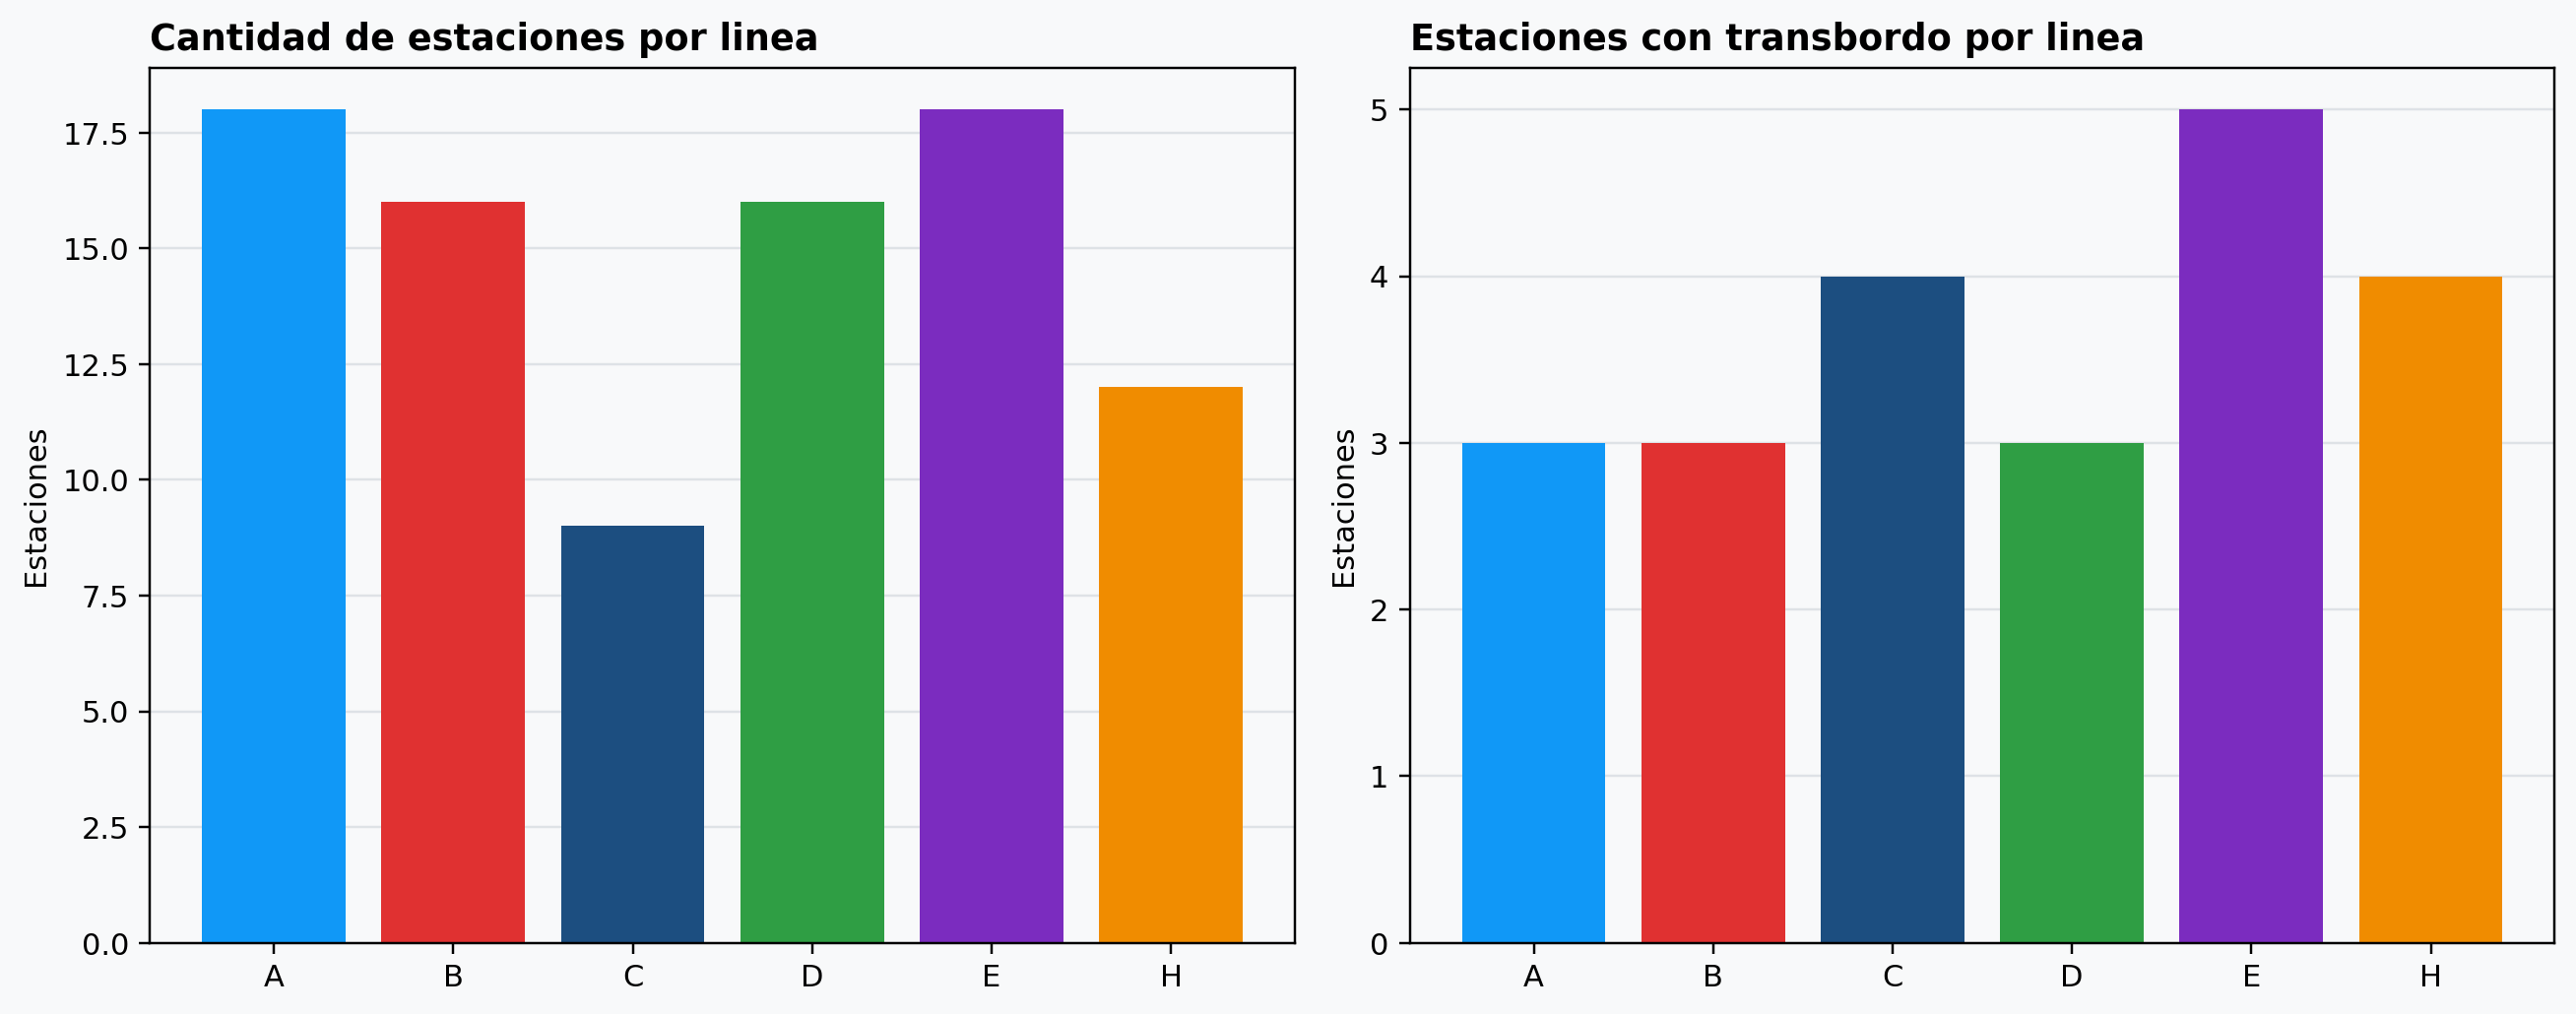

,linea,estaciones,estaciones_con_transbordo,cabeceras
0,A,18,3,2
1,B,16,3,2
2,C,9,4,2
3,D,16,3,2
4,E,18,5,2
5,H,12,4,2


In [7]:
display(Image(filename=str(FIGURES_DIR / 'resumen_por_linea.png')))
line_summary

## 6. Escenario futuro con las lineas F, G e I

Para recuperar el analisis de las estaciones nuevas, se modela un escenario que agrega la linea F oficial 2025 y las primeras etapas historicas de G e I. Esta seccion usa el mismo pipeline que genera la figura `red_subte_caba_futuro_esquematico.png` y las tablas exportadas en `outputs/`.

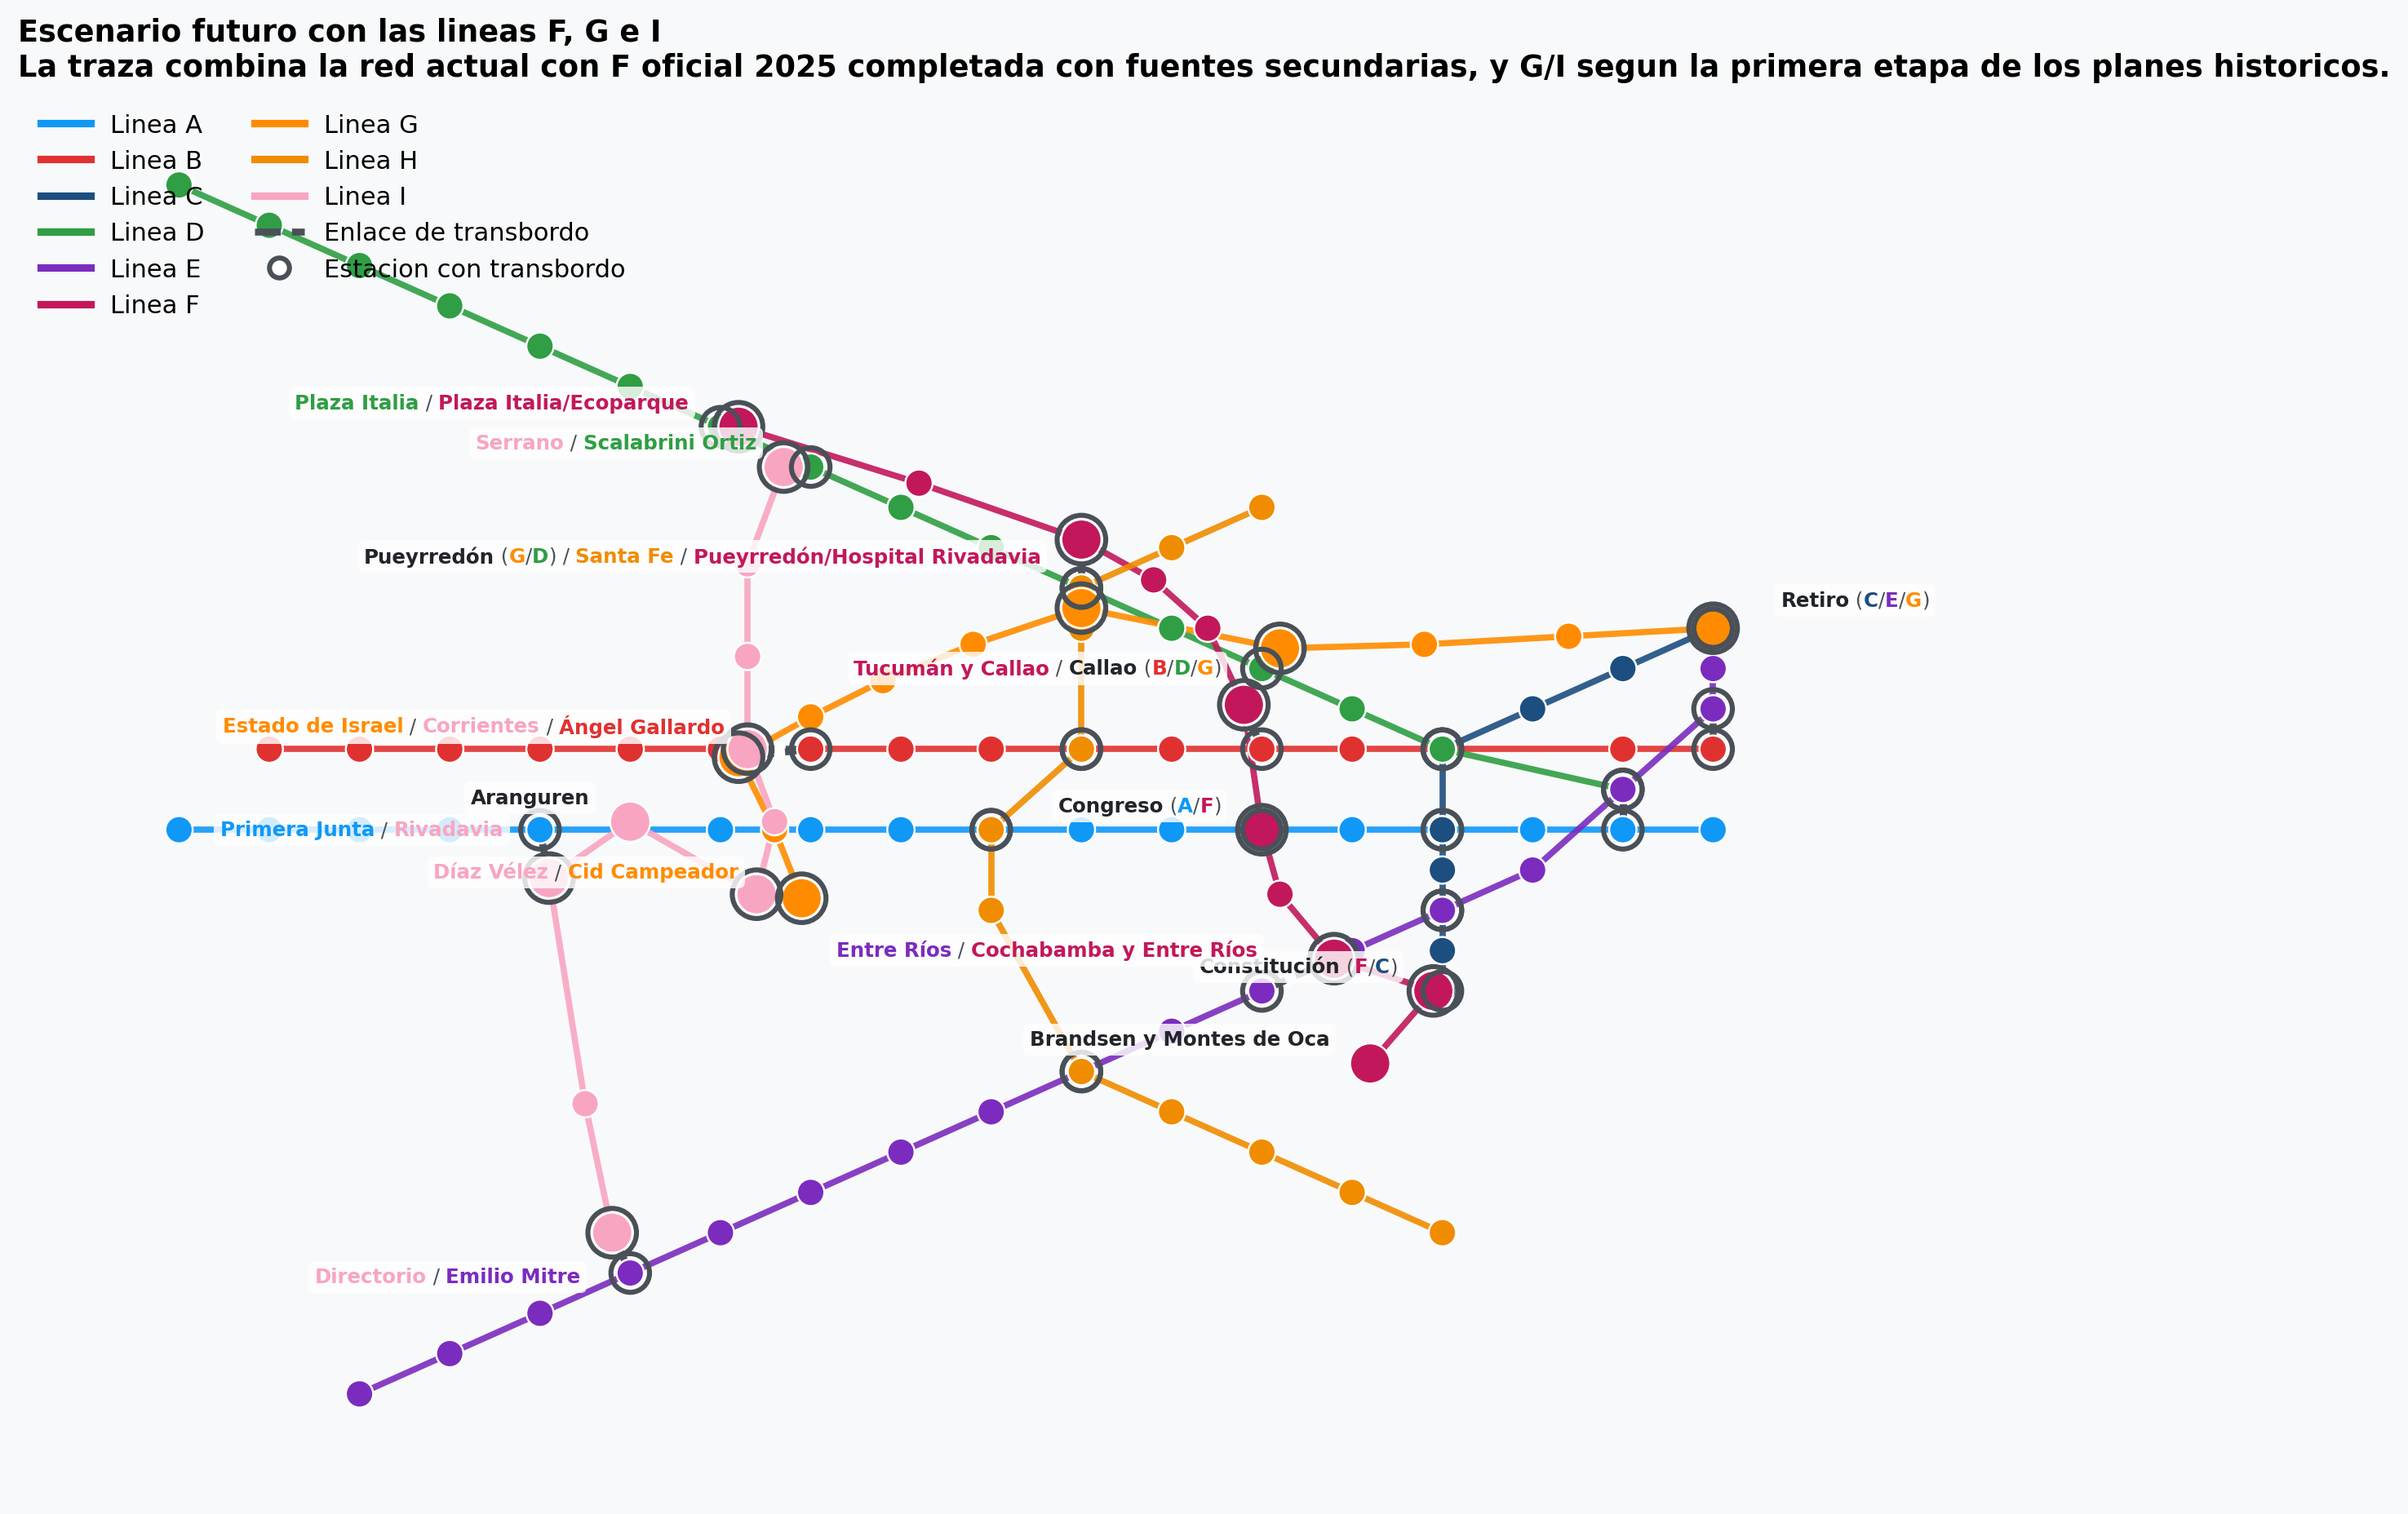

,escenario,estaciones_nuevas,transbordos_nuevos,tiempo_medio,mejora_tiempo_pct,eficiencia,mejora_eficiencia_pct,diametro,radio,caida_betweenness_hubs_pct,betweenness_nuevas_estaciones
0,F,11,7,22.93,1.25,0.07,0.74,58.0,29,10.63,0.52
1,G,11,5,23.10,0.53,0.07,0.23,58.0,30,2.70,0.23
2,I,10,4,22.40,3.55,0.07,1.21,49.0,30,24.30,0.64
3,F+G+I,32,18,22.05,5.07,0.07,2.10,49.0,29,33.41,1.19


In [8]:
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_futuro_esquematico.png')))

future_scenarios = future['scenario_table'].copy()
for column in [
    'tiempo_medio',
    'mejora_tiempo_pct',
    'eficiencia',
    'mejora_eficiencia_pct',
    'caida_betweenness_hubs_pct',
    'betweenness_nuevas_estaciones',
]:
    future_scenarios[column] = future_scenarios[column].round(2)

future_scenarios

Lectura rapida:

- La combinacion `F+G+I` es la que mas mejora la red: baja el tiempo medio entre estaciones actuales en torno a 5.1% y reduce 33.4% la betweenness acumulada de los hubs actuales.
- Entre las lineas evaluadas por separado, la I es la mas potente: recorta el tiempo medio 3.55% y descarga 24.3% del flujo de los nodos mas exigidos.
- La F agrega nuevos puntos de intercambio fuertes en el corredor central, mientras que la G suma conectividad lateral pero con un efecto mas acotado en esta primera etapa.

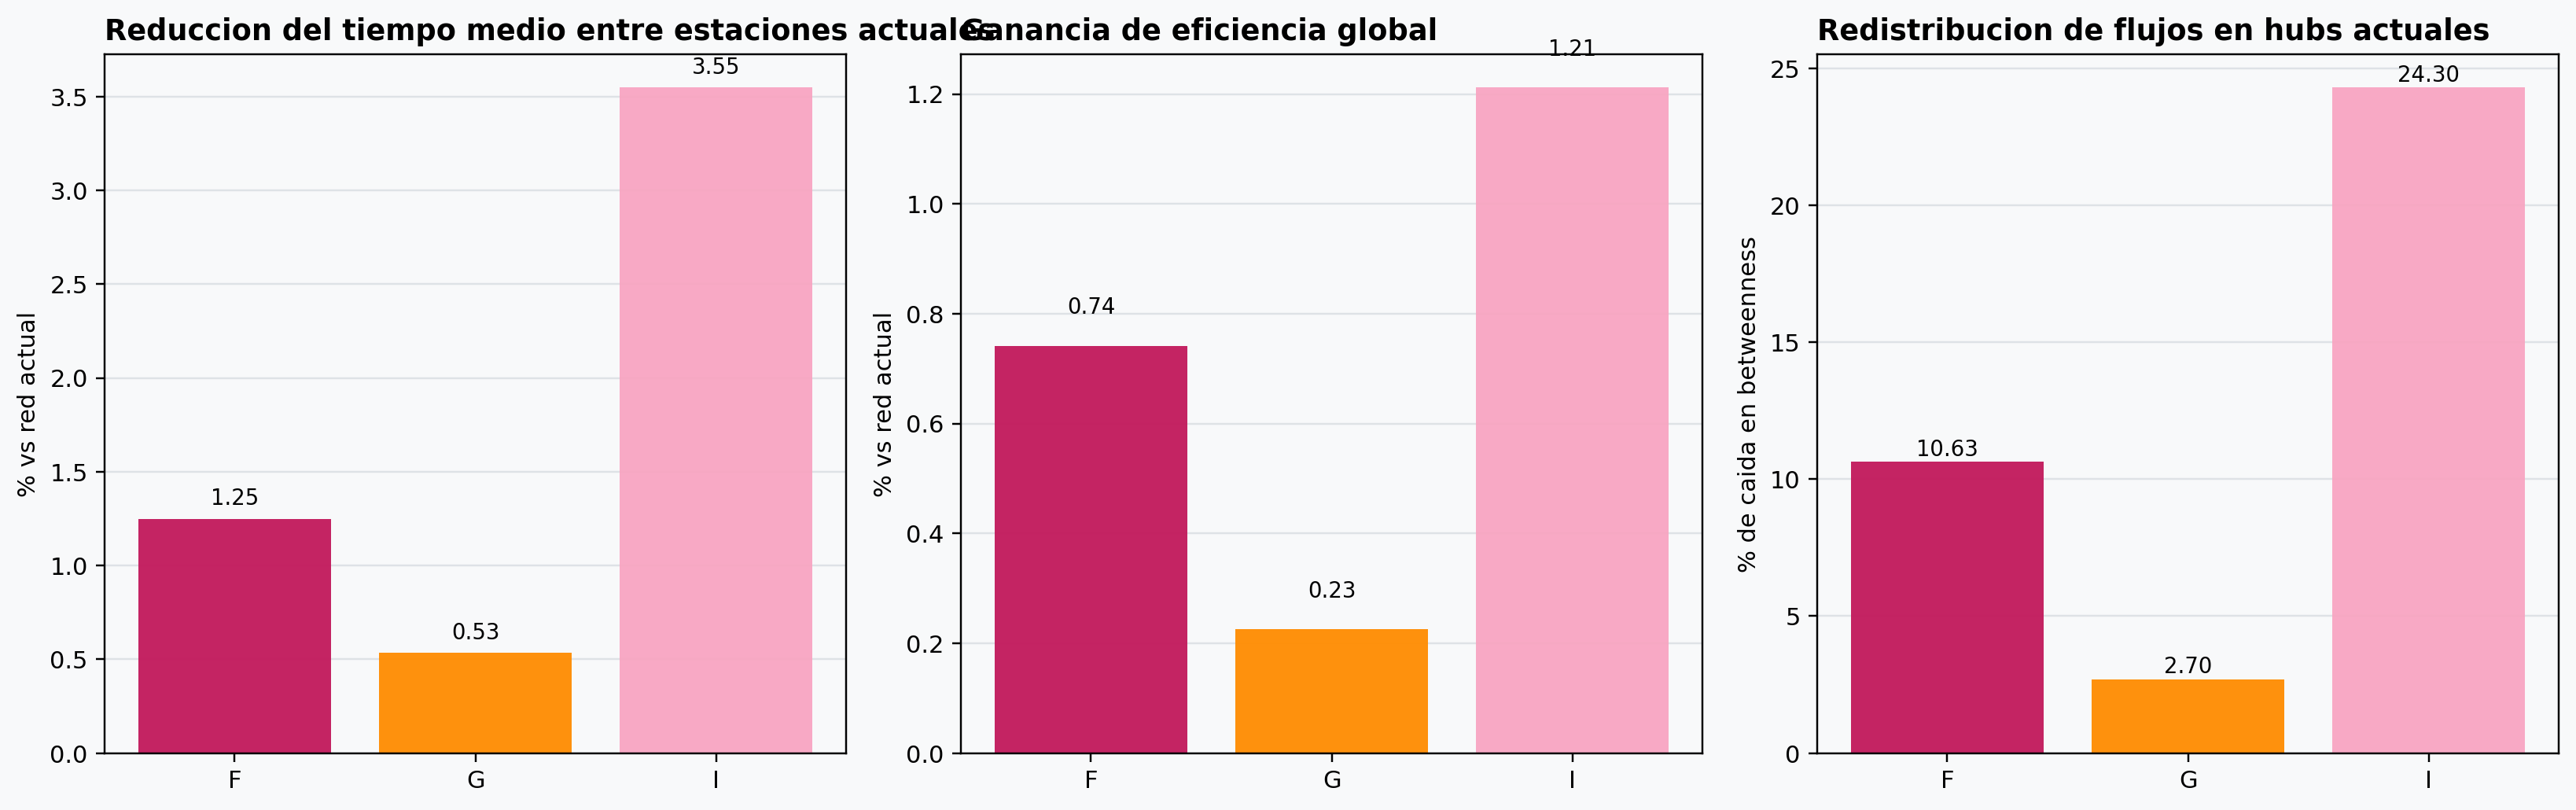

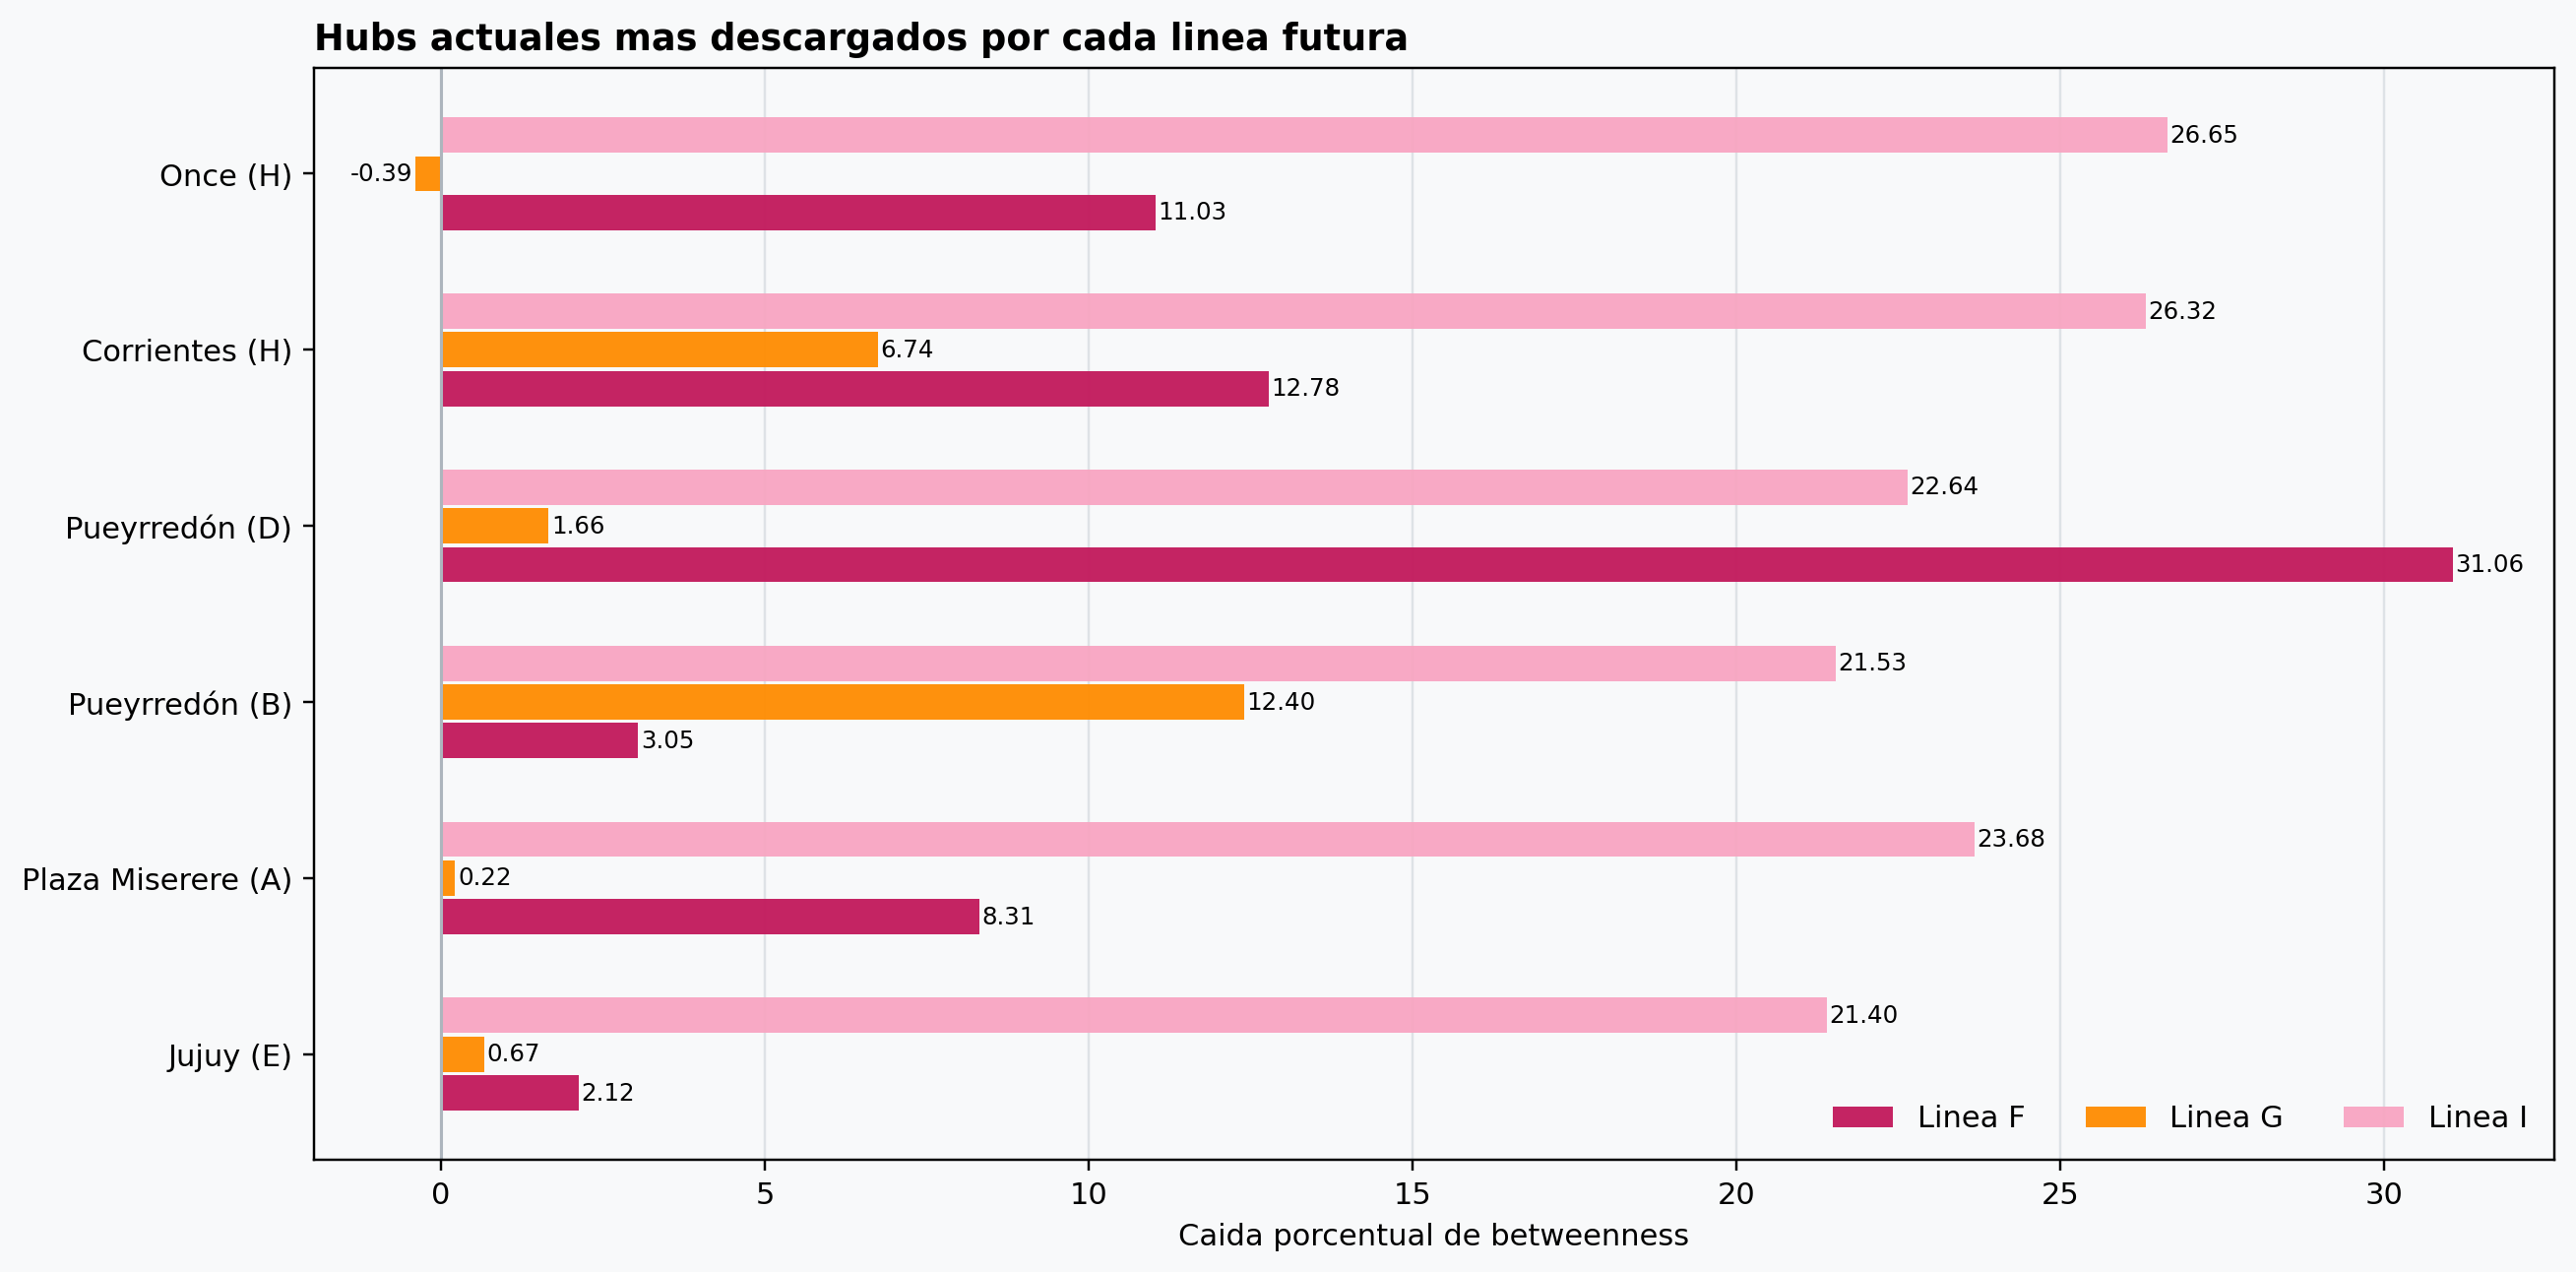

,criterio,ganadora_entre_F_G_I
0,reduccion de distancias entre estaciones actuales,I
1,redistribucion de flujos en hubs actuales,I


In [9]:
display(Image(filename=str(FIGURES_DIR / 'comparacion_lineas_futuras.png')))
display(Image(filename=str(FIGURES_DIR / 'alivio_hubs_futuros.png')))

pd.DataFrame(
    [
        {
            'criterio': 'reduccion de distancias entre estaciones actuales',
            'ganadora_entre_F_G_I': future['winners']['distance'],
        },
        {
            'criterio': 'redistribucion de flujos en hubs actuales',
            'ganadora_entre_F_G_I': future['winners']['redistribution'],
        },
    ]
)

Las nuevas estaciones con mayor centralidad quedan concentradas sobre los corredores I y F. En particular, `Rivadavia` (I) lidera la betweenness sobre demanda actual, mientras que `Tucuman y Callao` (F) aparece como el nodo mas fuerte cuando se combina intermediacion con cercania.

In [10]:
future_line_centrality = future['line_centrality'].copy()
for column in [
    'betweenness_demanda_actual_total',
    'betweenness_demanda_actual_media',
    'closeness_media',
]:
    future_line_centrality[column] = future_line_centrality[column].round(4)

future_line_centrality

,linea,estaciones_modeladas,betweenness_demanda_actual_total,betweenness_demanda_actual_media,closeness_media,top_estacion_betweenness,top_estacion_closeness
2,I,10,0.6249,0.0625,0.0447,Rivadavia,Corrientes
0,F,11,0.4236,0.0385,0.0536,Tucumán y Callao,Tucumán y Callao
1,G,11,0.1379,0.0125,0.0517,Pueyrredón,Pueyrredón


In [11]:
top_future = future['top_future_stations'].copy()
for column in ['betweenness_demanda_actual', 'betweenness', 'closeness', 'score_central']:
    top_future[column] = top_future[column].round(4)

top_future

,estacion,linea,betweenness_demanda_actual,betweenness,closeness,score_central
113,Rivadavia,I,0.0883,0.1144,0.0447,47.2
94,Tucumán y Callao,F,0.0824,0.1646,0.0618,1.4
117,Corrientes,I,0.0823,0.1048,0.0469,41.4
93,Congreso,F,0.0764,0.1387,0.0606,5.4
116,Warnes,I,0.0614,0.0755,0.0458,60.8
115,Díaz Vélez,I,0.0614,0.1025,0.0458,50.4
114,Aranguren,I,0.0614,0.0946,0.0449,58.8
112,Pedro Goyena,I,0.0551,0.0636,0.0429,72.2
111,Directorio,I,0.0551,0.0586,0.0417,75.8
118,Córdoba,I,0.0533,0.0628,0.0449,64.0


## 7. Conclusion

La red actual muestra una estructura claramente centralizada: los principales transbordos y las estaciones mas estrategicas se concentran en el corredor central, mientras que las cabeceras aparecen como nodos perifericos.

En el escenario futuro, la ampliacion con F, G e I mantiene esa logica pero reparte mejor los recorridos, sobre todo cuando se incorpora la linea I y, con mas fuerza aun, la combinacion completa de los tres proyectos. Desde el punto de vista de la conectividad, la linea H sigue siendo un conector transversal clave en la red actual, mientras que F e I aparecen como las expansiones con mayor capacidad para aliviar hubs existentes y abrir alternativas fuera del microcentro.